In [3922]:
# import
import polars as pl
import pyarrow as pa
import statsmodels.api as sm
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as mtrans
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as mtick
from matplotlib import cm
from matplotlib.patches import Patch
# for using Times New Roman
import matplotlib.font_manager
import os as os
import subprocess
import sys as sys
import re
import threading
import logging
import time
import math
import warnings
warnings.filterwarnings('ignore')

In [3923]:
# Using seaborn's style
plt.style.use(['ggplot', 'seaborn-v0_8-whitegrid'])

WIDTH = 345

def set_size(width, fraction=1):
    """ Set aesthetic figure dimensions to avoid scaling in latex.

    Parameters
    ----------
    width: float
            Width in pts
    fraction: float
            Fraction of the width which you wish the figure to occupy

    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio

    fig_dim = (fig_width_in, fig_height_in)

    return fig_dim

config = {
    "figure.figsize": set_size(WIDTH),
    "grid.linestyle": '--',
#     "hatch.color": '#eeeeee',
    "hatch.color": 'grey',
    "hatch.linewidth": 0.618,
    # Use LaTeX to write all text
    "text.usetex": False,
    "font.family": "Times New Roman",
    #"text.latex.unicode": True,
    "axes.unicode_minus": True,
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 22,
    "font.size": 22,
    "legend.fontsize": 22,
    # Make the label fonts a little smaller
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.handletextpad": 0.5,
    "legend.columnspacing": 0.9,
    "legend.numpoints": 3,
}

mpl.rcParams.update(config)

In [3924]:
gpus_per_node = 8
FIFO_Depth = 8

### comparison plot function

In [3925]:
import os
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

save_pdf_path="/Users/liuyaod/daily_report/AllReduce-Tree"

def plot_prediction_error(
    p2p_df: pl.DataFrame,
    y_ticks=None,
    y_labels=None,
    figsize=(120, 24),
    pdf_filename=None,
    xlabel="Msg Size (B)",
    ylabel="Pred. Error",
    legend=True,
    legend_loc="upper center",
    legend_ncol=3,
    protocol=None
):
    # Compute prediction error
    p2p_df = p2p_df.with_columns(
        ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() / pl.col("latency (us)")).alias("prediction_error")
    )
    df_pd = p2p_df.to_pandas()

    plt.rcParams['axes.edgecolor'] = 'black'
    plt.figure(figsize=figsize)

    for nch in sorted(df_pd["nnodes"].unique()):
        df_sub = df_pd[(df_pd["nnodes"] == nch)]
        plt.semilogx(
            df_sub["msg"],  # B
            df_sub["prediction_error"],
            marker='o',
            linestyle='None',
            label=f'{nch} Nodes',
            markersize=3,
            base=2
        )

    # plt.xticks([0, 131072, 17179869184], labels=["0", "128 K", "16 G"])

    if protocol == "LL":
        x_ticks = [2**i for i in range(10, 40, 10)]  # Adjust range as needed
        x_labels = ["1 K", "1 M", "1 G"]  # Separate strings with commas
        plt.xticks(x_ticks, labels=x_labels, rotation=0)
    else:
        # Create log2-based ticks
        x_ticks = [2**i for i in range(10, 50, 10)]  # Adjust range as needed
        x_labels = ["1 K", "1 M", "1 G", "1 T"]  # Separate strings with commas
        plt.xticks(x_ticks, labels=x_labels, rotation=0)


    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.ylim(bottom=0)
    plt.gca().yaxis.set_label_coords(-0.2, 0.4)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    if y_ticks and y_labels:
        plt.yticks(y_ticks, labels=y_labels)

    if legend:
        plt.legend(ncol=legend_ncol, loc=legend_loc, bbox_to_anchor=(0.4, -0.5),
                   handlelength=1.2, handletextpad=0, columnspacing=0)

    plt.grid(True)
    plt.tight_layout()

    if pdf_filename:
        full_path = os.path.join(save_pdf_path, pdf_filename)
        plt.savefig(full_path, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {full_path}")

    plt.show()

In [3926]:
import os
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

def plot_prediction_error_nodes(
    p2p_df: pl.DataFrame,
    y_ticks=None,
    y_labels=None,
    figsize=(120, 24),
    pdf_filename=None,
    xlabel="# Nodes",
    ylabel="Pred. Error",
    legend=True,
    legend_loc="upper center",
    legend_ncol=3,
):
    # Compute prediction error
    p2p_df = p2p_df.with_columns(
        ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() / pl.col("latency (us)")).alias("prediction_error")
    )
    df_pd = p2p_df.to_pandas()

    plt.rcParams['axes.edgecolor'] = 'black'
    plt.figure(figsize=figsize)

    for nch in sorted(df_pd["nnodes"].unique()):
        df_sub = df_pd[(df_pd["nnodes"] == nch)]
        plt.semilogx(
            df_sub["nnodes"], 
            df_sub["prediction_error"],
            marker='o',
            linestyle='None',
            label='None',
            markersize=3,
            base=2
        )

    # Create log2-based ticks
    x_ticks = [2**i for i in range(2, 8, 1)]  # Adjust range as needed
    x_labels = ["4", "8", "16", "32", "64", "128"]  # Separate strings with commas
    plt.xticks(x_ticks, labels=x_labels, rotation=0)


    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.ylim(bottom=0)
    plt.gca().yaxis.set_label_coords(-0.2, 0.4)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    if y_ticks and y_labels:
        plt.yticks(y_ticks, labels=y_labels)

    if legend:
        plt.legend(ncol=legend_ncol, loc=legend_loc, bbox_to_anchor=(0.4, -0.5),
                   handlelength=1.2, handletextpad=0, columnspacing=0)

    plt.grid(True)
    plt.tight_layout()

    if pdf_filename:
        full_path = os.path.join(save_pdf_path, pdf_filename)
        plt.savefig(full_path, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {full_path}")

    plt.show()

In [3927]:
def plot_latency_comparison(
    df,
    x_col='msg',
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured Latency', 'Predicted Latency'],
    markers=['o', '^'],
    colors=['#2980b9', '#e74c3c'],
    xlabel='Message Size (Bytes)',
    ylabel='Latency (ms)',  # Changed to ms
    pdf_filename='latency_comparison.pdf',
    protocol=None
):
    
    df = df.filter(pl.col("msg") < 18874368)

    # Convert to log scale for better visualization
    df_pandas = df.to_pandas().sort_values(by=x_col)
    
    # Convert microseconds to milliseconds
    df_pandas_ms = df_pandas.copy()
    for col in y_cols:
        df_pandas_ms[col] = df_pandas[col] / 1000.0  # Convert us to ms

    dim = set_size(WIDTH, fraction=1)
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    # Plot both lines (using millisecond values)
    for y, label, marker, color in zip(y_cols, labels, markers, colors):
        axe.plot(df_pandas_ms[x_col], df_pandas_ms[y], 
                label=label, marker=marker, markersize=4, 
                color=color, linewidth=1)

    # Set log scale for x-axis
    axe.set_xscale('log', base=2)

    # Set y-axis to start from 0
    axe.set_ylim(bottom=0)
    
    # Grid and axes settings
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Create log2-based ticks
    x_ticks = [2**i for i in range(12, 25, 2)]  # Adjust range as needed
    x_labels = ["4K", "16K", "64K", "256K", "1M", "4M", "16M"]  # Separate strings with commas
    plt.xticks(x_ticks, labels=x_labels, rotation=15)

    axe.set_xlabel(xlabel)
    axe.set_ylabel(ylabel)

    # Legend
    axe.legend(
        loc='upper left',
        frameon=False,
        handletextpad=0.5,
        columnspacing=1,
        handlelength=1.5
    )

    if protocol == "LL128":
        # Legend
        axe.legend(
            loc='lower right',
            frameon=False,
            handletextpad=0.5,
            columnspacing=1,
            handlelength=1.5
        )

    # Save to PDF if filename is provided
    if pdf_filename:
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {pdf_filename}")

    plt.show()

In [3928]:
def plot_latency_comparison_nodes(
    df,
    x_col='nnodes',
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured Latency', 'Predicted Latency'],
    markers=['o', '^'],
    colors=['#2980b9', '#e74c3c'],
    xlabel='# Nodes',
    ylabel='Latency (ms)',  # Changed to ms
    pdf_filename='latency_comparison.pdf',
    protocol=None
):
    
    # Convert to log scale for better visualization
    df_pandas = df.to_pandas().sort_values(by=x_col)
    
    # Convert microseconds to milliseconds
    df_pandas_ms = df_pandas.copy()
    for col in y_cols:
        df_pandas_ms[col] = df_pandas[col] / 1000.0  # Convert us to ms

    dim = set_size(WIDTH, fraction=1)
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    # Plot both lines (using millisecond values)
    for y, label, marker, color in zip(y_cols, labels, markers, colors):
        axe.plot(df_pandas_ms[x_col], df_pandas_ms[y], 
                label=label, marker=marker, markersize=4, 
                color=color, linewidth=1)

    # Set log scale for x-axis
    axe.set_xscale('log', base=2)
    
    # Grid and axes settings
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Create log2-based ticks
    x_ticks = [2**i for i in range(2, 8, 1)]  # Adjust range as needed
    x_labels = ["4", "8", "16", "32", "64", "128"]  # Separate strings with commas
    plt.xticks(x_ticks, labels=x_labels, rotation=0)

    if protocol == "LL":
        y_ticks = [0, 20, 40]  # Adjust range as needed
        y_labels = ["0", "20", "40"]  # Separate strings with commas
    elif protocol == "LL128":
        y_ticks = [0, 150, 300]  # Adjust range as needed
        y_labels = ["0", "150", "300"]  # Separate strings with commas
    else:
        y_ticks = [0, 120, 240]  # Adjust range as needed
        y_labels = ["0", "120", "240"]  # Separate strings with commas
    plt.yticks(y_ticks, labels=y_labels, rotation=0)

    axe.set_xlabel(xlabel)
    axe.set_ylabel(ylabel)

    # Legend
    axe.legend(
        loc='upper left',
        frameon=False,
        handletextpad=0.5,
        columnspacing=1,
        handlelength=1.5
    )

    # Save to PDF if filename is provided
    if pdf_filename:
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {pdf_filename}")

    plt.show()

In [3929]:
def plot_BW_comparison(
    df,
    x_col='msg',
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured BW', 'Predicted BW'],
    markers=['o', '^'],
    colors=['#2980b9', '#e74c3c'],
    xlabel='Message Size (Bytes)',
    ylabel='Latency (ms)',  # Changed to ms
    pdf_filename='latency_comparison.pdf',
    protocol=None
):
    
    df = df.filter(pl.col("msg") > 16777216)

    # Convert to log scale for better visualization
    df_pandas = df.to_pandas().sort_values(by=x_col)
    
    # Convert microseconds to milliseconds
    df_pandas_ms = df_pandas.copy()
    for col in y_cols:
        df_pandas_ms[col] = df_pandas[col]

    dim = set_size(WIDTH, fraction=1)
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    # Plot both lines (using millisecond values)
    for y, label, marker, color in zip(y_cols, labels, markers, colors):
        axe.plot(df_pandas_ms[x_col], df_pandas_ms[y], 
                label=label, marker=marker, markersize=4, 
                color=color, linewidth=1)

    # Set log scale for x-axis
    axe.set_xscale('log', base=2)

    # Set y-axis to start from 0
    axe.set_ylim(bottom=0)

    if protocol == "LL":
        y_ticks = [0, 30, 60]  # Adjust range as needed
        y_labels = ["0", "30", "60"]  # Separate strings with commas
        plt.yticks(y_ticks, labels=y_labels, rotation=0)
    
    # Grid and axes settings
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    if protocol == "LL":
        x_ticks = [2**i for i in range(24, 29, 2)]  # Adjust range as needed
        x_labels = ["16M", "64M", "256M"]  # Separate strings with commas
        plt.xticks(x_ticks, labels=x_labels, rotation=0)
    else:
        # Create log2-based ticks
        x_ticks = [2**i for i in range(25, 34, 2)]  # Adjust range as needed
        x_labels = ["32M", "128M", "512M", "2G", "8G"]  # Separate strings with commas
        plt.xticks(x_ticks, labels=x_labels, rotation=15)

    axe.set_xlabel(xlabel)
    axe.set_ylabel(ylabel)

    # Legend
    axe.legend(
        loc='lower right',  # correct syntax
        frameon=False,
        handletextpad=0.5,
        columnspacing=1,
        handlelength=1.5
    )

    # Save to PDF if filename is provided
    if pdf_filename:
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {pdf_filename}")

    plt.show()

### Read from Profiling

In [3930]:

import re
import polars as pl

def parse_send_timings(filename: str) -> pl.DataFrame:
    with open(filename, 'r') as f:
        text = f.read()

    # 1) find all the INFO headers
    info_re = re.compile(
        r"INFO: algo\((?P<algo>TREE|RING|NVLS_TREE|PAT)\)_protocol\((?P<protocol>Simple|LL|LL128)\)_mode\(allreduce\)_message size\((?P<message_size>\d+)\)"
        r"_nchannels\((?P<nchannels>\d+)\)"
        r"_nmessages\((?P<nmessages>\d+)\)"
        r"_iteration\((?P<iteration>\d+)\)"
    )
    info_matches = list(info_re.finditer(text))

    # Pattern for T0-T7 style chunks
    chunk_re = re.compile(
        r"-- \[T(?P<tag>[07])\] chunk (?P<chunk_id>\d+).*?"
        r"\(r(?P<source>\d+) to r(?P<dest>\d+)\) in channel (?P<channel>\d+): (?P<value>[\d.]+) ms"
    )

    # Additional pattern for T10 style chunks
    chunk_t10_re = re.compile(
        r"-- \[T(?P<tag>10)\] chunk 0 posted to chunk (?P<chunk_id>\d+) done time "
        r"\(r(?P<source>\d+) to r(?P<dest>\d+)\) in channel (?P<channel>\d+): (?P<value>[\d.]+) ms"
    )

    # Rest of the patterns remain the same
    t_tags_re = re.compile(
        r"-- \[T(?P<tag>[1289])\].*?time: (?P<value>[\d.]+) ms"
    )
    
    t_init_re = re.compile(
        r"-- \[T init\] nccl init time: (?P<value>[\d.]+) ms"
    )

    records = []
    for idx, m in enumerate(info_matches):
        meta = m.groupdict()  # Get all groups as strings first
        # Convert only numeric fields to int, keep protocol as string
        for k in ['message_size', 'nchannels', 'nmessages', 'iteration']:
            meta[k] = int(meta[k])
        start = m.end()
        end = info_matches[idx+1].start() if idx+1 < len(info_matches) else len(text)
        section = text[start:end]

        # Get T1, T2, T8, T9 timings
        t_timings = {
            f"T{e.group('tag')}": float(e.group('value'))
            for e in t_tags_re.finditer(section)
        }

        # Get init time
        ti = t_init_re.search(section)
        if ti:
            t_timings["T_init"] = float(ti.group("value"))

        # Process chunk data
        chunk_data = {}
        for c in chunk_re.finditer(section):
            cid = int(c.group("chunk_id"))
            ch = int(c.group("channel"))
            tag = f"T{c.group('tag')}"
            val = float(c.group('value'))
            source = int(c.group('source'))  # Extract source from regex
            dest = int(c.group('dest'))      # Extract dest from regex
            
            key = (cid, ch, meta["iteration"])
            if key not in chunk_data:
                chunk_data[key] = {
                    "chunk_id": cid,
                    "channel": ch,
                    "source": source,  # Use extracted values
                    "dest": dest,      # Use extracted values
                    **meta,
                    **t_timings
                }
            chunk_data[key][tag] = val

        # Process T10 chunks
        for c in chunk_t10_re.finditer(section):
            cid = int(c.group("chunk_id"))
            ch = int(c.group("channel"))
            tag = f"T{c.group('tag')}"
            val = float(c.group('value'))
            source = int(c.group('source'))
            dest = int(c.group('dest'))
            
            key = (cid, ch, meta["iteration"])
            if key not in chunk_data:
                chunk_data[key] = {
                    "chunk_id": cid,
                    "channel": ch,
                    "source": source,
                    "dest": dest,
                    **meta,
                    **t_timings
                }
            chunk_data[key][tag] = val

        records.extend(chunk_data.values())

    df = pl.DataFrame(records)
    print(f"Number of records: {len(records)}")  # Debug print
    return df

### Read from nccl-test data

In [3931]:
def parse_nccl_output(file_path, gpus_per_node, msg_size_thresholds=None):
    """
    Parse NCCL test output file and create a DataFrame with performance data.
    
    Args:
        file_path (str): Path to the NCCL test output file
        gpus_per_node (int): Number of GPUs per node
        msg_size_thresholds (dict): Dictionary of message size thresholds and corresponding nchannels
                                  Default: {
                                      32*1024: 1,
                                      64*1024: 2,
                                      128*1024: 4,
                                      512*1024: 8,
                                      float('inf'): 16
                                  }
    
    Returns:
        pl.DataFrame: DataFrame containing the parsed data
    """
    # Set default thresholds if none provided
    if msg_size_thresholds is None:
        msg_size_thresholds = {
            32*1024: 1,
            64*1024: 2,
            128*1024: 4,
            512*1024: 8,
            float('inf'): 16
        }

    # Initialize lists to store the data
    sizes = []
    times = []
    busbws = []

    # Initialize configuration variables
    protocol = "unknown"
    algorithm = "unknown"
    max_rank = -1

    # Read and process file
    with open(file_path, 'r') as file:
        content = file.read()
        
        # Parse protocol
        if "NCCL_PROTO=" in content:
            protocol = content.split("NCCL_PROTO=")[1].split()[0].strip()
        
        # Parse algorithm
        if "NCCL_ALGO=" in content:
            algorithm = content.split("NCCL_ALGO=")[1].split()[0].strip()
        
        # Find max rank number
        for line in content.split('\n'):
            if line.startswith("#  Rank"):
                try:
                    rank_num = int(line.split()[2])
                    max_rank = max(max_rank, rank_num)
                except (ValueError, IndexError):
                    continue

        nnodes = (max_rank + 1)/gpus_per_node

        # Parse performance data
        for line in content.split('\n'):
            parts = line.strip().split()
            if len(parts) >= 8:
                try:
                    if (parts[0].replace(',', '').isdigit() and
                        parts[1].replace(',', '').isdigit() and
                        parts[2] == "float"):
                        
                        size = int(parts[0].replace(',', ''))
                        time = float(parts[5])
                        busbw = float(parts[7])
                        
                        sizes.append(size)
                        times.append(time)
                        busbws.append(busbw)
                except ValueError:
                    continue

    # Create DataFrame
    df = pl.DataFrame({
        "msg": sizes,
        "latency (us)": times,
        "BW (GB/s)": busbws
    })

    # Add configuration parameters
    df = df.with_columns([
        pl.lit(algorithm.upper()).alias("algorithm"),
        pl.lit(nnodes).alias("nnodes"),
        pl.lit(protocol).alias("protocol")
    ])

    # Add nchannels based on message size
    when_then_chain = pl.when(pl.col("msg") <= list(msg_size_thresholds.keys())[0])
    for i, (threshold, nchannels) in enumerate(msg_size_thresholds.items()):
        if i == 0:
            when_then_chain = when_then_chain.then(nchannels)
        elif i < len(msg_size_thresholds) - 1:
            when_then_chain = when_then_chain.when(pl.col("msg") <= threshold).then(nchannels)
        else:
            when_then_chain = when_then_chain.otherwise(nchannels)

    df_sweep_data_means = (df
        .sort("msg")
        .with_columns([when_then_chain.alias("nchannels")])
    )

    return df_sweep_data_means

### Simple

In [3932]:
custom_thresholds = {
    32*1024: 1,
    64*1024: 2,
    128*1024: 4,
    256*1024: 8,
    float('inf'): 16
}
df_sweep_data_simple_tree = parse_nccl_output("/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_test-allreduce-tree.out", gpus_per_node=gpus_per_node, msg_size_thresholds=custom_thresholds)

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    print(df_sweep_data_simple_tree.to_pandas())

             msg  latency (us)  BW (GB/s) algorithm  nnodes protocol  nchannels
0           4096         359.1       0.02      TREE    16.0   Simple          1
1           8192         367.9       0.04      TREE    16.0   Simple          1
2          16384         331.0       0.10      TREE    16.0   Simple          1
3          32768         370.4       0.18      TREE    16.0   Simple          1
4          65536         391.3       0.33      TREE    16.0   Simple          2
5         131072         386.7       0.67      TREE    16.0   Simple          4
6         262144         391.3       1.33      TREE    16.0   Simple          8
7         524288         394.3       2.64      TREE    16.0   Simple         16
8        1048576         456.8       4.56      TREE    16.0   Simple         16
9        2097152         540.9       7.69      TREE    16.0   Simple         16
10       4194304         726.3      11.46      TREE    16.0   Simple         16
11       8388608        1100.7      15.1

### Read from profiling

In [3933]:
# === File Paths ===
profiling_files = {
    "r0": "/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_allreduce_heo-inter_r-0.out",
    "r8": "/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_allreduce_heo-inter_r-8.out",
    "r16": "/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_allreduce_heo-inter_r-16.out",
    "r17": "/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_allreduce_heo-inter_r-17.out",
    "r24": "/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_allreduce_heo-inter_r-24.out",
}

# === Load Data ===
df_r0 = parse_send_timings(profiling_files["r0"])
df_r8 = parse_send_timings(profiling_files["r8"])
df_r16 = parse_send_timings(profiling_files["r16"])
df_r17 = parse_send_timings(profiling_files["r17"])
df_r24 = parse_send_timings(profiling_files["r24"])

df_r16_up = df_r16.filter(pl.col("dest") == 0)

df_r16_down = df_r16.filter(pl.col("dest") == 24)

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df_r16_up.to_pandas())


Number of records: 552
Number of records: 552
Number of records: 1104
Number of records: 552
Number of records: 552
     chunk_id  channel  source  dest  algo protocol  message_size  nchannels  nmessages  iteration        T1        T2        T9        T8       T_init        T0        T7       T10
0           0        0      16     0  TREE   Simple             8          1      10000          0  0.013723  0.086175  0.117501  0.090902  3467.643311  0.000000  0.030426  0.103778
1           0        0      16     0  TREE   Simple            64          2      10000          0  0.014227  0.123593  0.160007  0.090753  3424.197021  0.000000  0.035460  0.145780
2           0        0      16     0  TREE   Simple           128          4      10000          0  0.016312  0.112673  0.149584  0.140752  3449.567139  0.000000  0.036015  0.133272
3           0        0      16     0  TREE   Simple           256          8      10000          0  0.014841  0.114689  0.151808  0.150486  3338.144775  0.0

### Some Analysis

In [3934]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def analyze_large_chunk_speed(df):
    # (MB/ms = GB/s)

    max_msg = df['message_size'].max()

    df = df.filter(pl.col("message_size") == max_msg)

    max_chunk_id = df['chunk_id'].max()

    # Filter for the row with maximum chunk_id
    max_chunk_row = df.filter(pl.col("chunk_id") == max_chunk_id)

    min_chunk_row = df.filter(pl.col("chunk_id") == 0)

    # Calculate BW
    BW = max_chunk_row['message_size'] * 1e-3 / (max_chunk_row['T10'] - min_chunk_row['T10'])
    
    return BW.to_numpy()[0]

In [3935]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def analyze_L_timing(df, df1, min_message_size, max_message_size, large, plot_figure):
    # (KB/ms = 0.001 GB/s)    
    
    df_filtered = df.filter(
        (pl.col("message_size") >= min_message_size) & 
        (pl.col("message_size") <= max_message_size)
    )

    if df1 is None:
        df_filtered = (df_filtered
            .group_by(["message_size"])  # Include nchannels in group_by
            .agg([
                (pl.col("T9")-pl.col("T1")).mean().alias("o_mean"),
                pl.col("nchannels").first().alias("nchannels")  # Keep nchannels value
            ])
            .sort("message_size")
        )
    else:
        df_filtered1 = df1.filter(
            (pl.col("message_size") >= min_message_size) & 
            (pl.col("message_size") <= max_message_size)
        )
    
        df_filtered = (df_filtered
            .join(
                df_filtered1,
                on="message_size",
                suffix="_right"  # Add suffix to avoid column name conflicts
            )
            .group_by(["message_size"])
            .agg([
                ((pl.col("T9") - pl.col("T1")) - (pl.col("T9_right") - pl.col("T1_right"))).mean().alias("o_mean"),
                pl.col("nchannels").first().alias("nchannels")
            ])
            .sort("message_size")
        )
    
    # Calculate X and y
    X = (df_filtered['message_size'] * 0.001).to_numpy().reshape(-1, 1)
    y = (df_filtered['o_mean']).to_numpy()

    # Perform linear regression
    reg = LinearRegression().fit(X, y)
    k = reg.coef_[0]   # slope
    s = reg.intercept_ # intercept
    r2 = reg.score(X, y)  # R-squared value
    
    if plot_figure == 1:
        # Create plot
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='blue', label='Actual data')
        plt.plot(X, reg.predict(X), color='red', label=f'Fitted line: y = {k:.6f}x + {s:.6f}')
        plt.xlabel('Message Size (MB)')
        plt.ylabel('Processing Time (ms)')
        plt.title(f't_i vs Message Size (R² = {r2:.4f})')
        plt.legend()
        plt.grid(True)
        plt.show()

    if large == 1:
        L = y.mean() * 1e3
        o = 0
        print(f"L + o (us) = {(o+L):.3f}, R-squared value is {r2:.6f}, when msg is large, chunk size is constant, L + o is stable")
    else:
        L = s * 1e3
        o = k # us/KB
        print(f"o = {o:.3f} (us/KB), L (us) = {L:.3f}, R-squared value is {r2:.6f}")
    
    return o, L

def analyze_all_L_timings(df_r24, df_r16_up, df_r0, df_r16_down, small_msg_start, small_msg_end, large_msg_start, large_msg_end, plot_figure=0):
    # Dictionary to store all results
    results = {}
    
    # Configurations
    configs = [
        # (name, dataframe, min_size, max_size)
        ('send', df_r24),
        ('rrs', df_r16_up),
        ('rrcs', df_r0),
        ('rcs', df_r16_down)
    ]

   
    o, L = analyze_L_timing(df_r24, None, small_msg_start, small_msg_end, 0, plot_figure)
    results[f'L_send_small'] = L
    results[f'o_send_small'] = o

    o, L = analyze_L_timing(df_r16_up, df_r24, small_msg_start, small_msg_end, 0, plot_figure)
    results[f'L_rrs_small'] = L
    results[f'o_rrs_small'] = o

    o, L = analyze_L_timing(df_r0, df_r16_up, small_msg_start, small_msg_end, 0, plot_figure)
    results[f'L_rrcs_small'] = L
    results[f'o_rrcs_small'] = o

    o, L = analyze_L_timing(df_r16_down, df_r0, small_msg_start, small_msg_end, 0, plot_figure)
    results[f'L_rcs_small'] = L
    results[f'o_rcs_small'] = o
    
    o, L = analyze_L_timing(df_r24, None, large_msg_start, large_msg_end, 0, plot_figure)
    results[f'L_send_large'] = L
    results[f'o_send_large'] = o

    o, L = analyze_L_timing(df_r16_up, df_r24, large_msg_start, large_msg_end, 0, plot_figure)
    results[f'L_rrs_large'] = L
    results[f'o_rrs_large'] = o

    o, L = analyze_L_timing(df_r0, df_r16_up, large_msg_start, large_msg_end, 0, plot_figure)
    results[f'L_rrcs_large'] = L
    results[f'o_rrcs_large'] = o

    o, L = analyze_L_timing(df_r16_down, df_r0, large_msg_start, large_msg_end, 0, plot_figure)
    results[f'L_rcs_large'] = L
    results[f'o_rcs_large'] = o
    
    return results

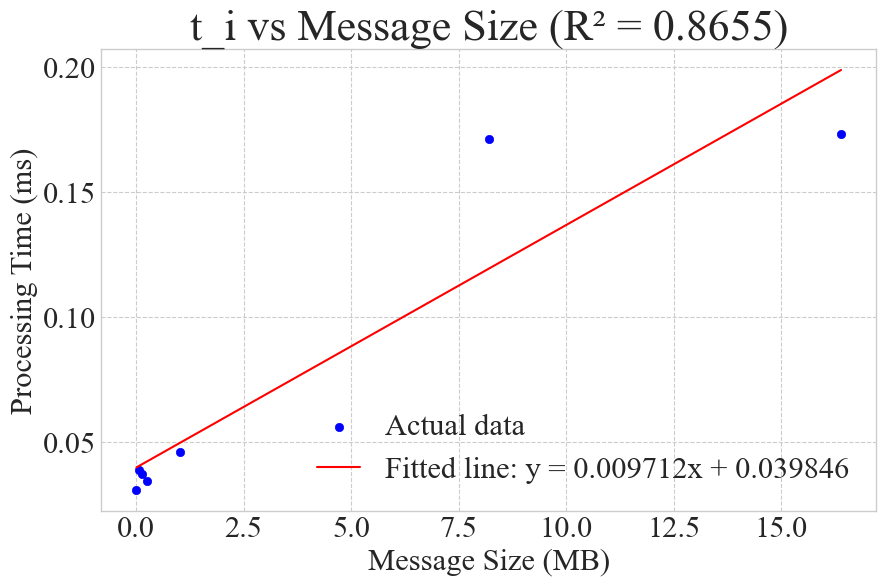

o = 0.010 (us/KB), L (us) = 39.846, R-squared value is 0.865459


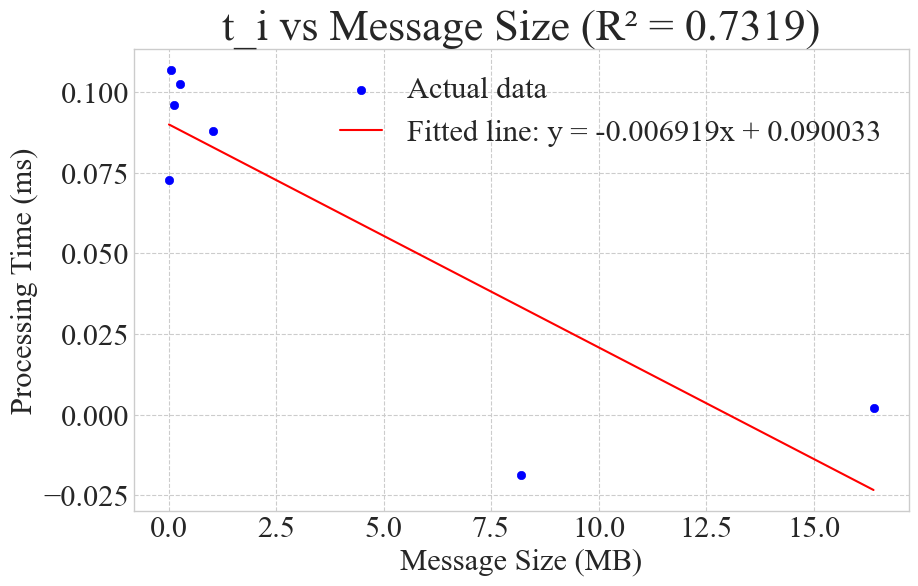

o = -0.007 (us/KB), L (us) = 90.033, R-squared value is 0.731885


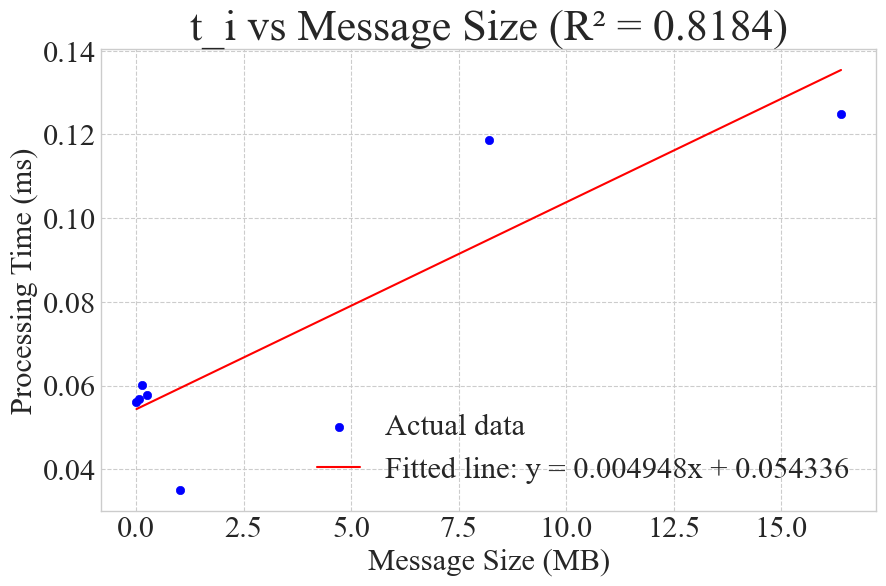

o = 0.005 (us/KB), L (us) = 54.336, R-squared value is 0.818401


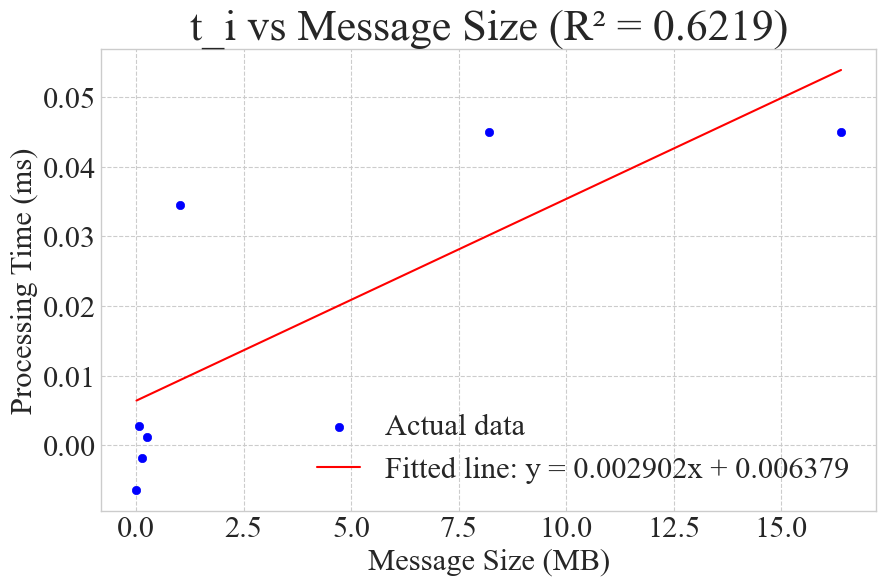

o = 0.003 (us/KB), L (us) = 6.379, R-squared value is 0.621927


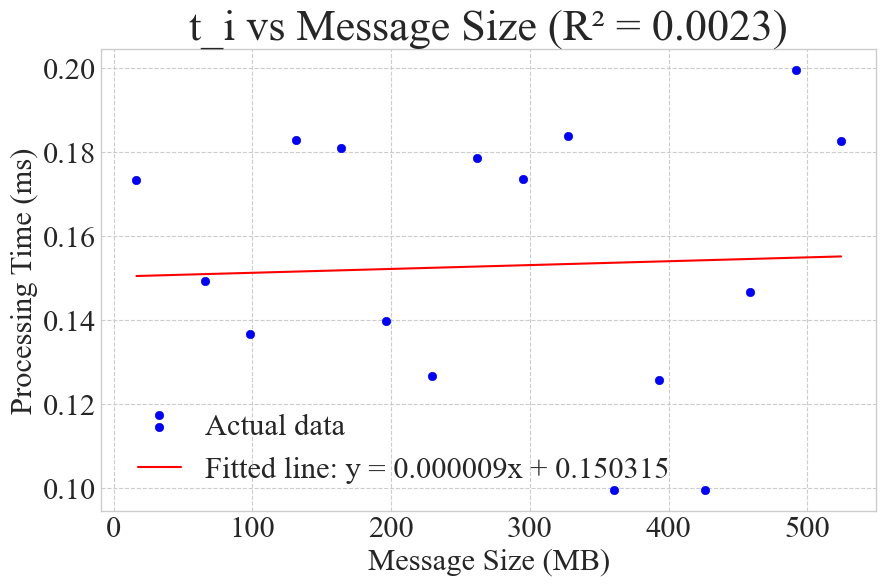

o = 0.000 (us/KB), L (us) = 150.315, R-squared value is 0.002253


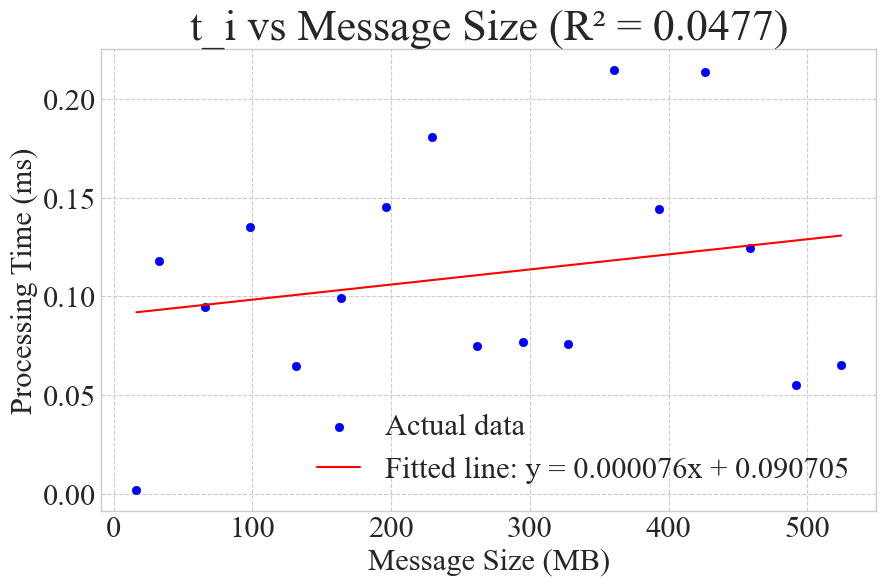

o = 0.000 (us/KB), L (us) = 90.705, R-squared value is 0.047682


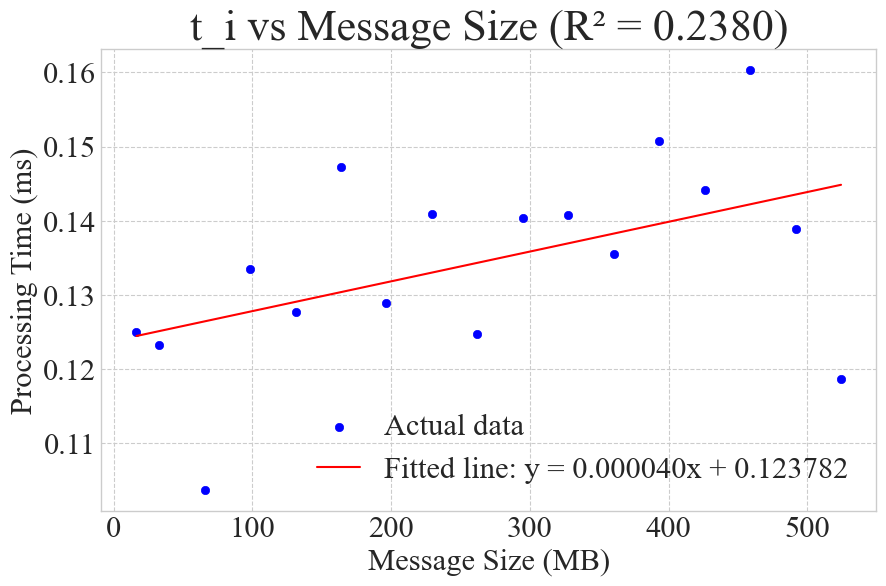

o = 0.000 (us/KB), L (us) = 123.782, R-squared value is 0.238032


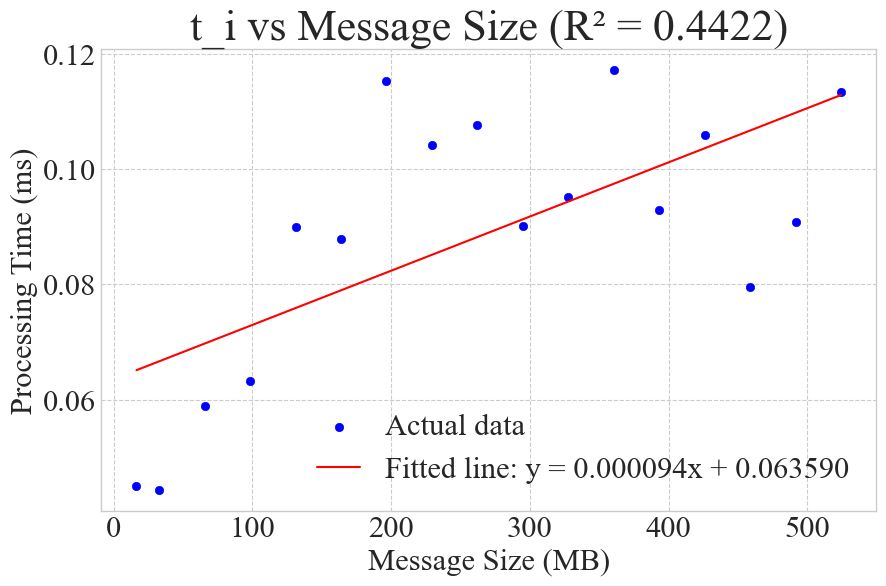

o = 0.000 (us/KB), L (us) = 63.590, R-squared value is 0.442199


In [3936]:
chunk_size = 0.5 # MB
number_channels = 16

inflection_point = chunk_size * 1024 * number_channels * 2

results = analyze_all_L_timings(df_r24, df_r16_up, df_r0, df_r16_down, 8, inflection_point, inflection_point, 524288, 1)

# Large message results
L_send_large = results['L_send_large']
L_rrs_large = results['L_rrs_large']
L_rrcs_large = results['L_rrcs_large']
L_rcs_large = results['L_rcs_large']

# Small message results
L_send_small = results['L_send_small']
L_rrs_small = results['L_rrs_small']
L_rrcs_small = results['L_rrcs_small']
L_rcs_small = results['L_rcs_small']
o_send_small = results['o_send_small']
o_rrs_small = results['o_rrs_small']
o_rrcs_small = results['o_rrcs_small']
o_rcs_small = results['o_rcs_small']


In [3937]:
import statistics

def analyze_chunk_speeds(dataframes):
    """
    Analyze both small and large chunk speeds for multiple dataframes.
    
    Parameters:
    dataframes: dict or list of dataframes to analyze
    message_size_for_G: message size parameter
    chunk_size: chunk size parameter
    offset: offset parameter for small chunk analysis (default 0)
    
    Returns:
    tuple: (G_small, G_large) minimum values for small and large chunk speeds
    """
    # If input is a dictionary, convert to list of dataframes
    if isinstance(dataframes, dict):
        dfs = list(dataframes.values())
    else:
        dfs = dataframes
    
    # Analyze large chunk speeds
    BW = min([
        analyze_large_chunk_speed(df)
        for df in dfs
    ])
    
    return BW

# Usage:
# Option 1: Using a list of dataframes
dataframes = [df_r0, df_r8, df_r16_up, df_r16_down, df_r17, df_r24]
BW = analyze_chunk_speeds(dataframes)

print(f"the BW for the tree is {BW: 3f} GB/s")

the BW for the tree is  163.719666 GB/s


### Model Varification V1

             msg  latency (us)  BW (GB/s) algorithm  nnodes protocol  nchannels  latency_pre (us)  BW_pre (GB/s)  prediction_error (%)
0           4096         359.1       0.02      TREE    16.0   Simple          1        383.427312       0.021198              6.774523
1           8192         367.9       0.04      TREE    16.0   Simple          1        383.437997       0.042395              4.223429
2          16384         331.0       0.10      TREE    16.0   Simple          1        383.459367       0.084786             15.848751
3          32768         370.4       0.18      TREE    16.0   Simple          1        383.502107       0.169553              3.537286
4          65536         391.3       0.33      TREE    16.0   Simple          2        383.587587       0.339031              1.970972
5         131072         386.7       0.67      TREE    16.0   Simple          4        383.758546       0.677759              0.760655
6         262144         391.3       1.33      TREE    

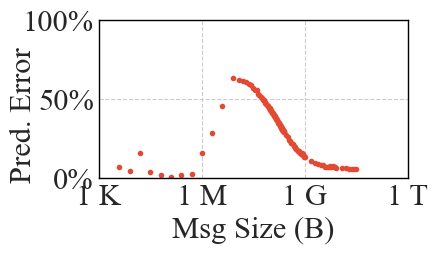

In [3938]:
# use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.

gpus_per_node = 8
chunk_size = 0.5 # MB
number_channels = 16

#first chunk data copy/reduce time + first chunk communication time + addtional chunks communication time
df_sweep_data_simple_tree_v1 = df_sweep_data_simple_tree.with_columns([
    (pl.when(pl.min_horizontal(chunk_size*number_channels, pl.col("msg")/1e6) * 1e3 * o_rrs_small + L_rrs_small < L_rrs_large)
     .then(
         # Small message case
         ((pl.min_horizontal(chunk_size*number_channels, pl.col("msg")/1e6) * 1e3 * 
           ((o_rrs_small + o_rcs_small) * (pl.col("nnodes").log(2)-1) + o_send_small + o_rrcs_small)) 
          + L_send_small + (pl.col("nnodes").log(2)-1) * (L_rrs_small + L_rcs_small) + L_rrcs_small
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size, 0) * 1e3 / BW)
     )
     .otherwise(
         # Large message case
         (
          L_send_large + (pl.col("nnodes").log(2)-1) * (L_rrs_large + L_rcs_large) + L_rrcs_large
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size, 0) * 1e3 / BW)
     )).alias("latency_pre (us)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_simple_tree_v1 = df_sweep_data_simple_tree_v1.with_columns([
    (pl.col("msg") * 0.001 * (2*(pl.col("nnodes") * gpus_per_node - 1)/(pl.col("nnodes") * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_simple_tree_v1_csv = df_sweep_data_simple_tree_v1.with_columns([
    ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
])

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df_sweep_data_simple_tree_v1_csv.to_pandas())

df_sweep_data_simple_tree_v1_csv.to_pandas().to_csv('model0.csv', index=False)

plot_prediction_error(
    df_sweep_data_simple_tree_v1,
    figsize=(5, 3),
    pdf_filename="allreduce_tree_simple_pre_error_v1.pdf",
    y_ticks=[0.0, 0.50, 1.00],
    y_labels=["0%", "50%", "100%"],
    xlabel="Msg Size (B)",
    ylabel="Pred. Error",
    legend=False
)

📄 Plot saved to: allreduce_tree_simple_pre_comparison_v1.pdf


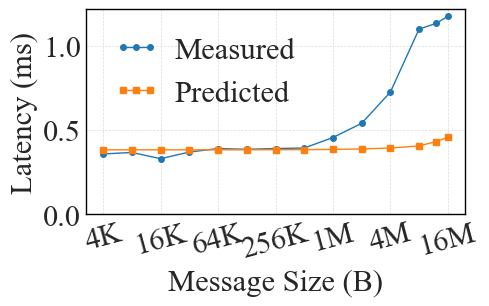

In [3939]:
plot_latency_comparison(
    df=df_sweep_data_simple_tree_v1,
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='Latency (ms)',
    pdf_filename='allreduce_tree_simple_pre_comparison_v1.pdf' 
)

📄 Plot saved to: allreduce_tree_simple_BW_pre_comparison_v1.pdf


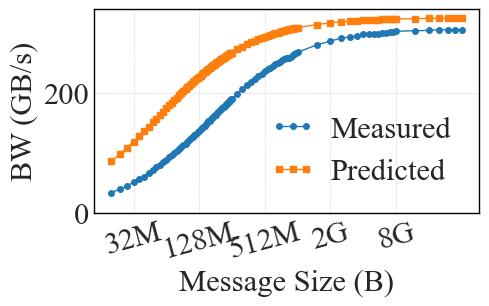

In [3940]:
plot_BW_comparison(
    df=df_sweep_data_simple_tree_v1,
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='BW (GB/s)',
    pdf_filename='allreduce_tree_simple_BW_pre_comparison_v1.pdf' 
)

### GPU Scale Prediction

In [3941]:
# df_sweep_data_simple_tree = df_sweep_data_means.filter(
#     (pl.col("algorithm") == "tree") & 
#     (pl.col("protocol") == "simple") & 
#     (pl.col("msg") == 17179869184) &
#     (pl.col("nnodes") > 2) 
# )

# print(df_sweep_data_simple_tree)

In [3942]:
# # use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.

# gpus_per_node = 8
# chunk_size = 0.5 # MB
# number_channels = 16

# df_sweep_data_simple_tree_v1 = df_sweep_data_simple_tree.with_columns([
#     (pl.when(pl.col("msg") < 1048576)
#      .then(
#          # Small message case
#          ((pl.min_horizontal(chunk_size*number_channels, pl.col("msg")/1e6) * 1e3 * 
#            ((G_rrs_reverse_small + G_rcs_reverse_small) * (pl.col("nnodes").log(2)-1) + G_send_reverse_small + G_rrcs_reverse_small)) 
#           + L_send_small + (pl.col("nnodes").log(2)-1) * (L_rrs_small + L_rcs_small) + L_rrcs_small
#           + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size, 0) * 1e3 / G_small)
#      )
#      .otherwise(
#          # Large message case
#          ((pl.min_horizontal(chunk_size*number_channels, pl.col("msg")/1e6) * 1e3 * 
#            ((G_rrs_reverse_large + G_rcs_reverse_large) * (pl.col("nnodes").log(2)-1) + G_send_reverse_large + G_rrcs_reverse_large)) 
#           + L_send_large + (pl.col("nnodes").log(2)-1) * (L_rrs_large + L_rcs_large) + L_rrcs_large
#           + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size, 0) * 1e3 / G_large)
#      )).alias("latency_pre (us)")
# ])

# # Then, create the bandwidth column using the newly created latency column
# df_sweep_data_simple_tree_v1 = df_sweep_data_simple_tree_v1.with_columns([
#     (pl.col("msg") * 0.001 * (2*(pl.col("nnodes") * gpus_per_node - 1)/(pl.col("nnodes") * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
# ])

# # Then, create the bandwidth column using the newly created latency column
# df_sweep_data_simple_tree_v1_csv = df_sweep_data_simple_tree_v1.with_columns([
#     ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
# ])

# with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
#         print(df_sweep_data_simple_tree_v1_csv.to_pandas())

# df_sweep_data_simple_tree_v1_csv.to_pandas().to_csv('model0.csv', index=False)

# plot_prediction_error_nodes(
#     df_sweep_data_simple_tree_v1,
#     figsize=(5, 3),
#     pdf_filename="allreduce_tree_simple_pre_error_v1_nodes.pdf",
#     y_ticks=[0.0, 0.02, 0.04],
#     y_labels=["0%", "2%", "4%"],
#     xlabel="# Nodes",
#     ylabel="Pred. Error",
#     legend=False
# )

In [3943]:
# plot_latency_comparison_nodes(
#     df=df_sweep_data_simple_tree_v1,
#     y_cols=['latency (us)', 'latency_pre (us)'],
#     labels=['Measured', 'Predicted'],
#     markers=['o', 's'],
#     colors=['#1f77b4', '#ff7f0e'],
#     xlabel='# Nodes',
#     ylabel='Latency (ms)',
#     pdf_filename='allreduce_tree_simple_pre_comparison_v1_nodes.pdf' 
# )

### LL

In [3944]:
custom_thresholds = {
    128*1024: 1,
    256*1024: 2,
    512*1024: 4,
    1024*1024: 8,
    float('inf'): 16
}
df_sweep_data_ll_tree = parse_nccl_output("/Users/liuyaod/daily_report/AllReduce-Tree/LL_profiling_results/nccl_test-allreduce-tree.out", gpus_per_node=gpus_per_node, msg_size_thresholds=custom_thresholds)

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    print(df_sweep_data_ll_tree.to_pandas())

          msg  latency (us)  BW (GB/s) algorithm  nnodes protocol  nchannels
0        4096         307.4       0.03      TREE    16.0       LL          1
1        8192         202.1       0.08      TREE    16.0       LL          1
2       16384         204.0       0.16      TREE    16.0       LL          1
3       32768         207.4       0.31      TREE    16.0       LL          1
4       65536         212.5       0.61      TREE    16.0       LL          1
5      131072         223.5       1.16      TREE    16.0       LL          1
6      262144         250.5       2.08      TREE    16.0       LL          2
7      524288         307.1       3.39      TREE    16.0       LL          4
8     1048576         331.5       6.28      TREE    16.0       LL          8
9     2097152         391.7      10.62      TREE    16.0       LL         16
10    4194304         444.1      18.74      TREE    16.0       LL         16
11    8388608         681.6      24.42      TREE    16.0       LL         16

In [3945]:
# Read from profiling

# === File Paths ===
profiling_files_LL = {
    "r0": "/Users/liuyaod/daily_report/AllReduce-Tree/LL_profiling_results/nccl_allreduce_heo-inter_r-0.out",
    "r8": "/Users/liuyaod/daily_report/AllReduce-Tree/LL_profiling_results/nccl_allreduce_heo-inter_r-8.out",
    "r16": "/Users/liuyaod/daily_report/AllReduce-Tree/LL_profiling_results/nccl_allreduce_heo-inter_r-16.out",
    "r17": "/Users/liuyaod/daily_report/AllReduce-Tree/LL_profiling_results/nccl_allreduce_heo-inter_r-17.out",
    "r24": "/Users/liuyaod/daily_report/AllReduce-Tree/LL_profiling_results/nccl_allreduce_heo-inter_r-24.out",
}

# === Load Data ===
df_r0_LL = parse_send_timings(profiling_files_LL["r0"])
df_r8_LL = parse_send_timings(profiling_files_LL["r8"])
df_r16_LL = parse_send_timings(profiling_files_LL["r16"])
df_r17_LL = parse_send_timings(profiling_files_LL["r17"])
df_r24_LL = parse_send_timings(profiling_files_LL["r24"])

df_r16_up_LL = df_r16_LL.filter(pl.col("dest") == 0)

df_r16_down_LL = df_r16_LL.filter(pl.col("dest") == 24)

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df_r16_up_LL.to_pandas())


Number of records: 549
Number of records: 549
Number of records: 1098
Number of records: 549
Number of records: 549
     chunk_id  channel  source  dest  algo protocol  message_size  nchannels  nmessages  iteration        T1        T2        T9        T8       T_init        T0        T7       T10
0           0        0      16     0  TREE       LL           128         16      10000          0  0.014570  0.064344  0.098923  0.111834  3455.199463  0.000000  0.033697  0.084353
1           0        0      16     0  TREE       LL           256         16      10000          0  0.014928  0.055039  0.096134  0.137853  3332.062988  0.000000  0.040196  0.081206
2           0        0      16     0  TREE       LL           512         16      10000          0  0.014896  0.067489  0.109082  0.140454  3512.193115  0.000000  0.040668  0.094187
3           0        0      16     0  TREE       LL          1024         16      10000          0  0.015326  0.059050  0.098495  0.151481  3418.318359  0.0

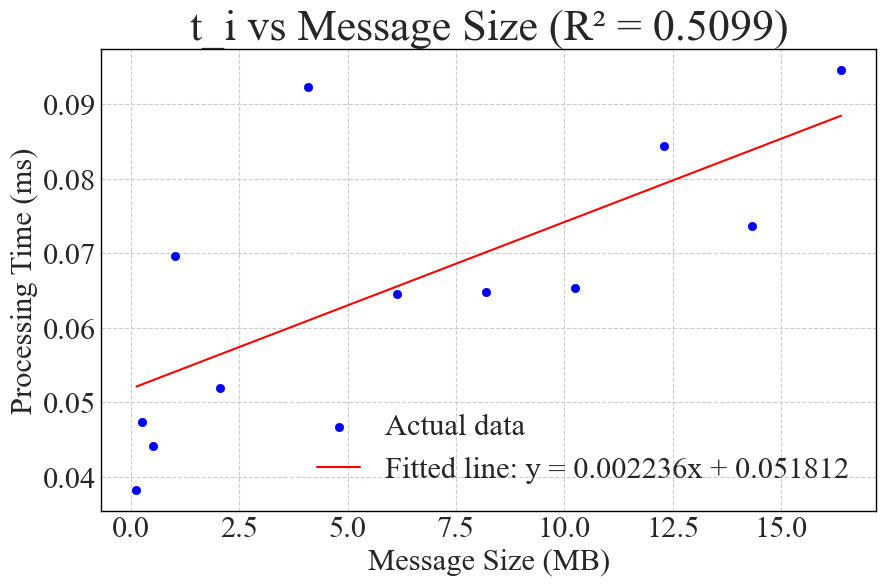

o = 0.002 (us/KB), L (us) = 51.812, R-squared value is 0.509858


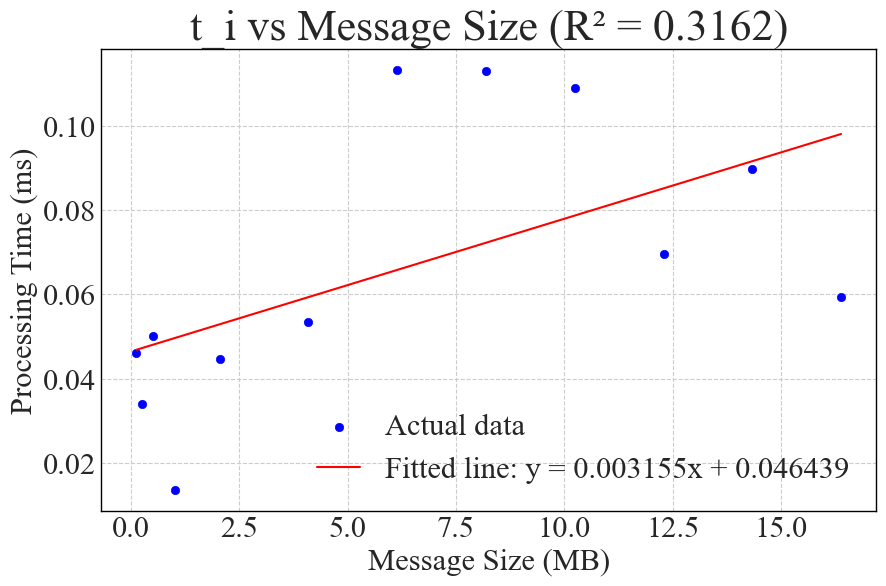

o = 0.003 (us/KB), L (us) = 46.439, R-squared value is 0.316236


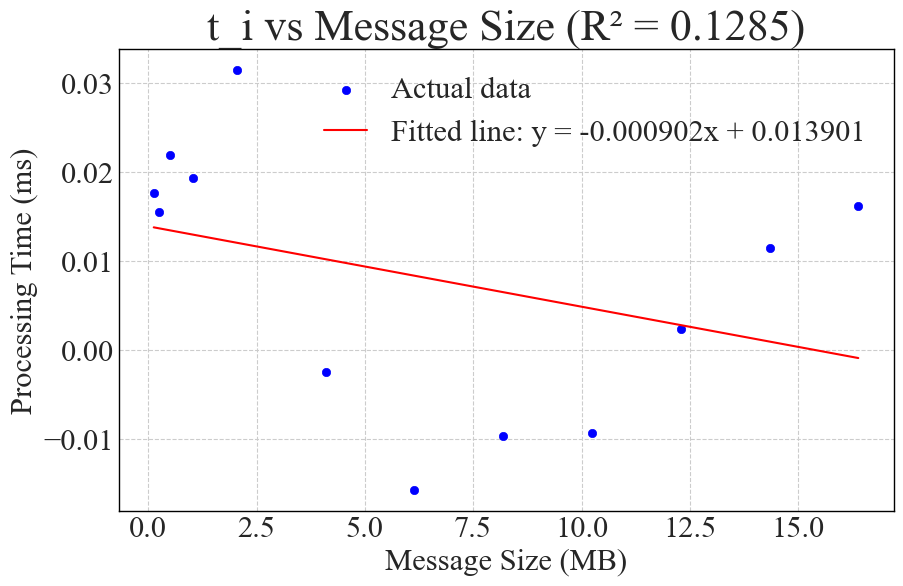

o = -0.001 (us/KB), L (us) = 13.901, R-squared value is 0.128484


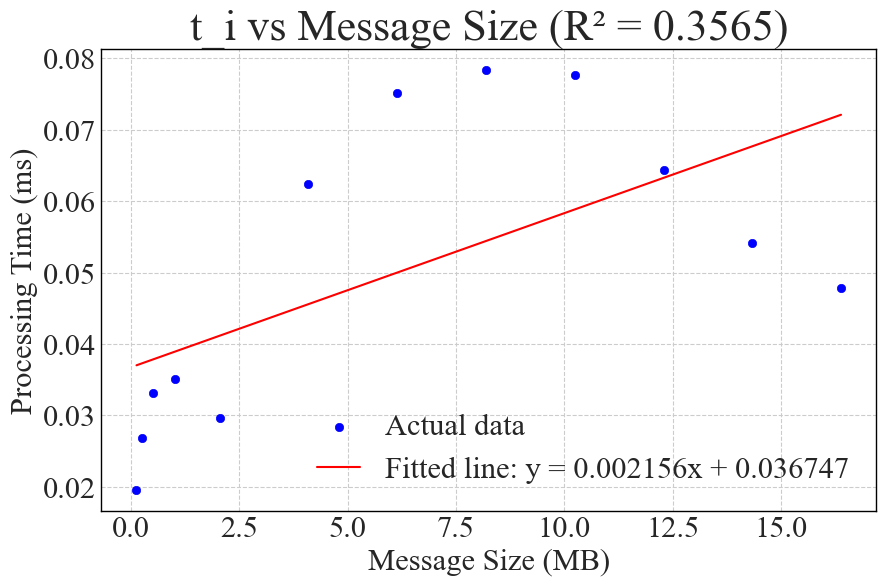

o = 0.002 (us/KB), L (us) = 36.747, R-squared value is 0.356531


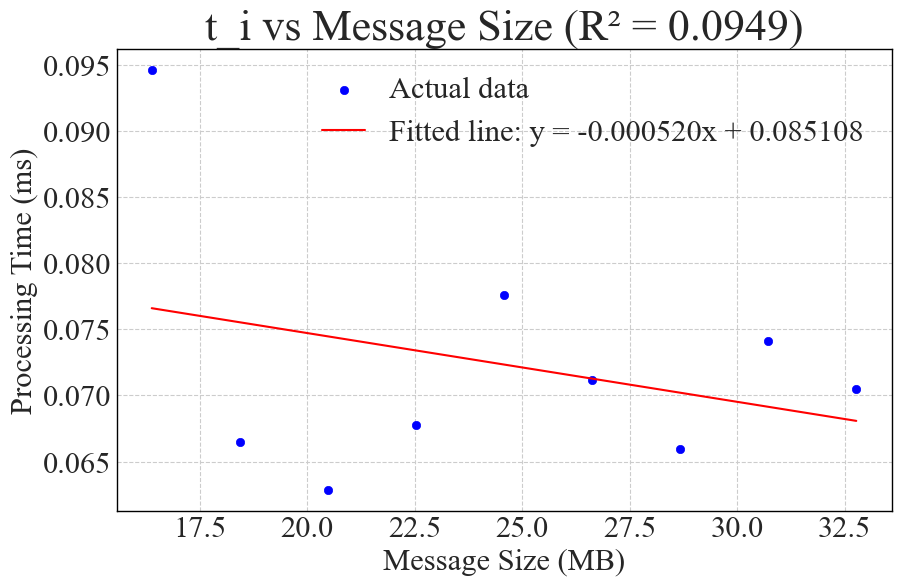

o = -0.001 (us/KB), L (us) = 85.108, R-squared value is 0.094942


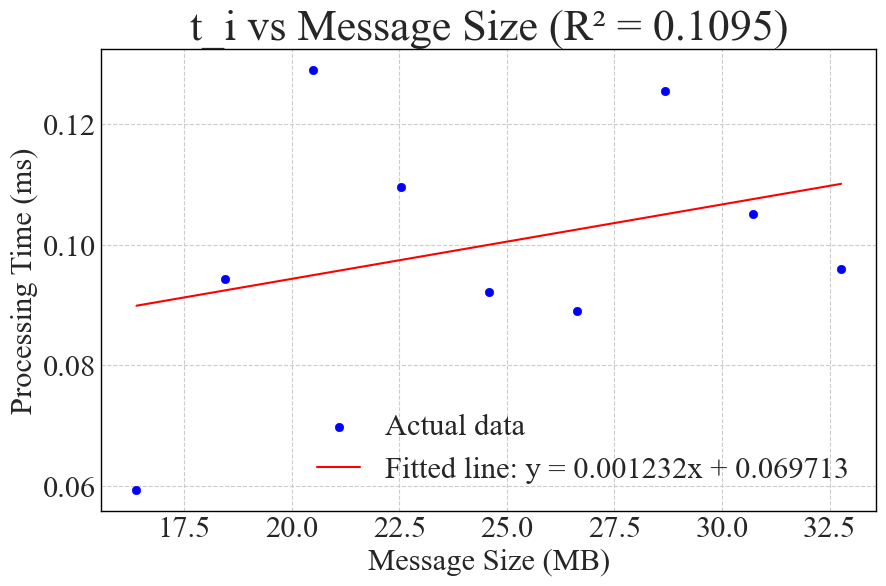

o = 0.001 (us/KB), L (us) = 69.713, R-squared value is 0.109460


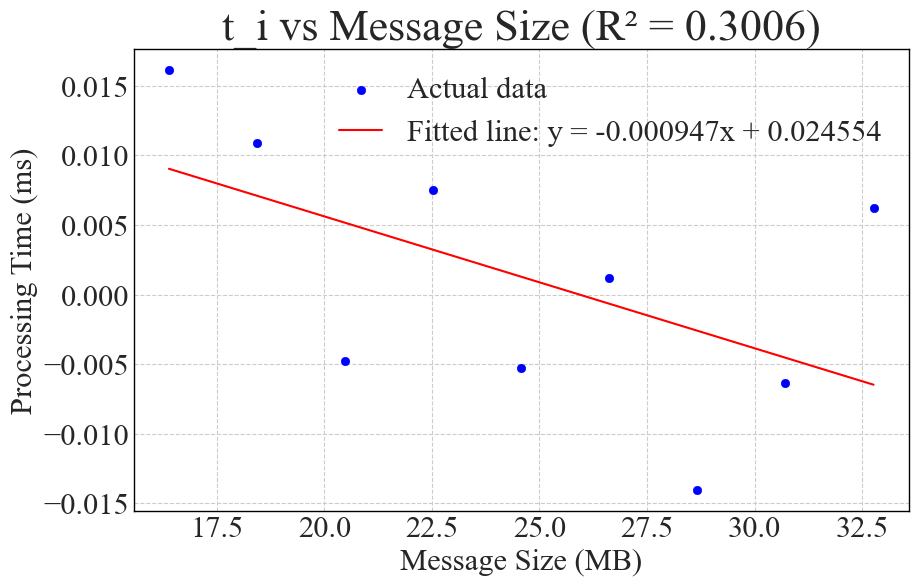

o = -0.001 (us/KB), L (us) = 24.554, R-squared value is 0.300600


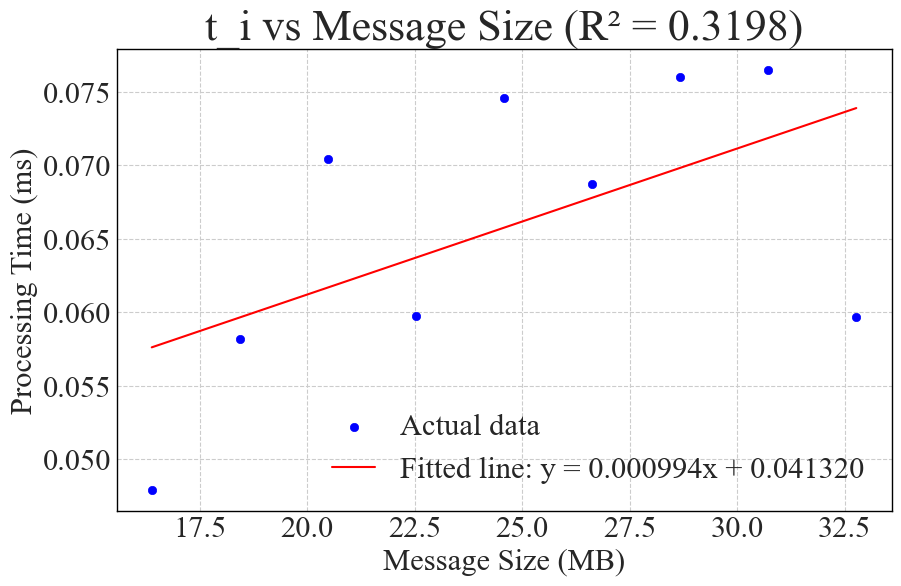

o = 0.001 (us/KB), L (us) = 41.320, R-squared value is 0.319751


In [3946]:
# Use the function
chunk_size_LL = 0.03125 # MB
number_channels = 16

inflection_point = chunk_size_LL * 1024 * number_channels * 32

results = analyze_all_L_timings(df_r24_LL, df_r16_up_LL, df_r0_LL, df_r16_down_LL, 16, inflection_point, inflection_point, 524288, 1)

# Large message results
L_send_large_LL = results['L_send_large']
L_rrs_large_LL = results['L_rrs_large']
L_rrcs_large_LL = results['L_rrcs_large']
L_rcs_large_LL = results['L_rcs_large']

# Small message results
L_send_small_LL = results['L_send_small']
L_rrs_small_LL = results['L_rrs_small']
L_rrcs_small_LL = results['L_rrcs_small']
L_rcs_small_LL = results['L_rcs_small']

o_send_small_LL = results['o_send_small']
o_rrs_small_LL = results['o_rrs_small']
o_rrcs_small_LL = results['o_rrcs_small']
o_rcs_small_LL = results['o_rcs_small']

In [3947]:
import statistics

# Option 1: Using a list of dataframes
dataframes = [df_r0_LL, df_r8_LL, df_r16_up_LL, df_r16_down_LL, df_r17_LL, df_r24_LL]
BW = analyze_chunk_speeds(dataframes)

print(f"the BW for the tree is {BW: 3f} GB/s")

the BW for the tree is  18.326571 GB/s


          msg  latency (us)  BW (GB/s) algorithm  nnodes protocol  nchannels  latency_pre (us)  BW_pre (GB/s)  prediction_error (%)
0        4096         307.4       0.03      TREE    16.0       LL          1        315.282443       0.025780              2.564230
1        8192         202.1       0.08      TREE    16.0       LL          1        315.293128       0.051558             56.008475
2       16384         204.0       0.16      TREE    16.0       LL          1        315.314498       0.103110             54.565931
3       32768         207.4       0.31      TREE    16.0       LL          1        315.357238       0.206192             52.052670
4       65536         212.5       0.61      TREE    16.0       LL          1        315.442718       0.412271             48.443632
5      131072         223.5       1.16      TREE    16.0       LL          1        315.613677       0.824096             41.214173
6      262144         250.5       2.08      TREE    16.0       LL          2

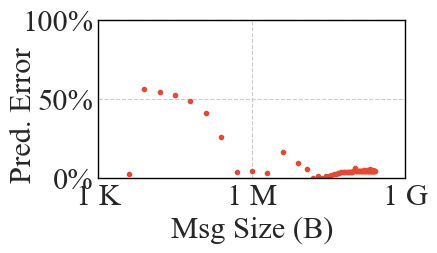

In [3948]:
# use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.

number_nodes = 16
gpus_per_node = 8
chunk_size_LL = 0.03125 # MB
number_channels = 16

# In the LL protocol, I discovered that the reduce/copy time for the first chunk is not needed, 
# as LL protocol appears to skip this operation. 
# In contrast, the Simple protocol requires this operation, 
# as evidenced by the reduceCopy() function in primitives_simple.h.
df_sweep_data_ll_tree_v1 = df_sweep_data_ll_tree.with_columns([
    (pl.when((pl.min_horizontal(chunk_size_LL*number_channels, pl.col("msg")/1e6) * 1e3 * o_rrs_small_LL + L_rrs_small_LL) < L_rrs_large_LL)
     .then(
         # Small message case
         ((pl.min_horizontal(chunk_size_LL*number_channels, pl.col("msg")/1e6) * 1e3 * 
           ((o_rrs_small + o_rcs_small) * (pl.col("nnodes").log(2)-1) + o_send_small + o_rrcs_small)) 
          + L_send_small_LL + (pl.col("nnodes").log(2)-1) * (L_rrs_small_LL + L_rcs_small_LL) + L_rrcs_small_LL
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL, 0) * 1e3 / BW)
     )
     .otherwise(
         # Large message case
         (L_send_large_LL + (pl.col("nnodes").log(2)-1) * (L_rrs_large_LL + L_rcs_large_LL) + L_rrcs_large_LL
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL, 0) * 1e3 / BW)
     )).alias("latency_pre (us)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_ll_tree_v1 = df_sweep_data_ll_tree_v1.with_columns([
    (pl.col("msg") * 0.001 * (2*(pl.col("nnodes") * gpus_per_node - 1)/(pl.col("nnodes") * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_ll_tree_v1_csv = df_sweep_data_ll_tree_v1.with_columns([
    ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
])

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df_sweep_data_ll_tree_v1_csv.to_pandas())

df_sweep_data_ll_tree_v1_csv.to_pandas().to_csv('model0.csv', index=False)

plot_prediction_error(
    df_sweep_data_ll_tree_v1,
    figsize=(5, 3),
    pdf_filename="allreduce_tree_LL_pre_error_v1.pdf",
    y_ticks=[0.0, 0.50, 1.00],
    y_labels=["0%", "50%", "100%"],
    xlabel="Msg Size (B)",
    ylabel="Pred. Error",
    legend=False,
    protocol="LL"
)

📄 Plot saved to: allreduce_tree_LL_pre_comparison_v1.pdf


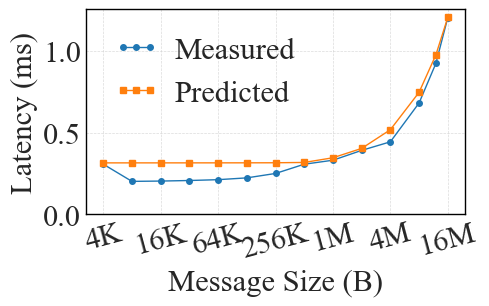

In [3949]:
plot_latency_comparison(
    df=df_sweep_data_ll_tree_v1,
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='Latency (ms)',
    pdf_filename='allreduce_tree_LL_pre_comparison_v1.pdf' 
)

📄 Plot saved to: allreduce_tree_LL_BW_pre_comparison_v1.pdf


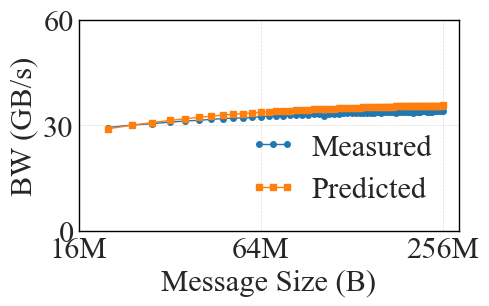

In [3950]:
plot_BW_comparison(
    df=df_sweep_data_ll_tree_v1,
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='BW (GB/s)',
    pdf_filename='allreduce_tree_LL_BW_pre_comparison_v1.pdf',
    protocol="LL"
)

### GPU Scale Prediction

In [3951]:
# df_sweep_data_ll_tree = df_sweep_data_means.filter(
#     (pl.col("algorithm") == "tree") & 
#     (pl.col("protocol") == "ll") & 
#     (pl.col("msg") == 268435456) &
#     (pl.col("nnodes") > 2) 
# )

# print(df_sweep_data_ll_tree)

In [3952]:
# # use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.

# gpus_per_node = 8
# chunk_size_LL = 0.03125 # MB
# number_channels = 16

# # In the LL protocol, I discovered that the reduce/copy time for the first chunk is not needed, 
# # as LL protocol appears to skip this operation. 
# # In contrast, the Simple protocol requires this operation, 
# # as evidenced by the reduceCopy() function in primitives_simple.h.
# df_sweep_data_ll_tree_v1 = df_sweep_data_ll_tree.with_columns([
#     (pl.when(pl.col("msg") < 65536)
#      .then(
#          # Small message case
#          ((pl.min_horizontal(chunk_size_LL*number_channels, pl.col("msg")/1e6) * 1e3 * 
#            ((G_rrs_reverse_small_LL + G_rcs_reverse_small_LL) * (pl.col("nnodes").log(2)-1) + G_send_reverse_small_LL + G_rrcs_reverse_small_LL)) 
#           + L_send_small_LL + (pl.col("nnodes").log(2)-1) * (L_rrs_small_LL + L_rcs_small_LL) + L_rrcs_small_LL
#           + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL, 0) * 1e3 / G_LL_small)
#      )
#      .otherwise(
#          # Large message case
#          ((pl.min_horizontal(chunk_size_LL*number_channels, pl.col("msg")/1e6) * 1e3 * 
#            ((G_rrs_reverse_large_LL + G_rcs_reverse_large_LL) * (pl.col("nnodes").log(2)-1) + G_send_reverse_large_LL + G_rrcs_reverse_large_LL)) 
#           + L_send_large_LL + (pl.col("nnodes").log(2)-1) * (L_rrs_large_LL + L_rcs_large_LL) + L_rrcs_large_LL
#           + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL, 0) * 1e3 / G_LL_large)
#      )).alias("latency_pre (us)")
# ])

# # Then, create the bandwidth column using the newly created latency column
# df_sweep_data_ll_tree_v1 = df_sweep_data_ll_tree_v1.with_columns([
#     (pl.col("msg") * 0.001 * (2*(pl.col("nnodes") * gpus_per_node - 1)/(pl.col("nnodes") * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
# ])

# # Then, create the bandwidth column using the newly created latency column
# df_sweep_data_ll_tree_v1_csv = df_sweep_data_ll_tree_v1.with_columns([
#     ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
# ])

# with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
#         print(df_sweep_data_ll_tree_v1_csv.to_pandas())

# df_sweep_data_ll_tree_v1_csv.to_pandas().to_csv('model0.csv', index=False)

# plot_prediction_error_nodes(
#     df_sweep_data_ll_tree_v1,
#     figsize=(5, 3),
#     pdf_filename="allreduce_tree_LL_pre_error_v1_nodes.pdf",
#     y_ticks=[0.0, 0.04, 0.08],
#     y_labels=["0%", "4%", "8%"],
#     xlabel="# Nodes",
#     ylabel="Pred. Error",
#     legend=False
# )

In [3953]:
# plot_latency_comparison_nodes(
#     df=df_sweep_data_ll_tree_v1,
#     y_cols=['latency (us)', 'latency_pre (us)'],
#     labels=['Measured', 'Predicted'],
#     markers=['o', 's'],
#     colors=['#1f77b4', '#ff7f0e'],
#     xlabel='# Nodes',
#     ylabel='Latency (ms)',
#     pdf_filename='allreduce_tree_ll_pre_comparison_v1_nodes.pdf',
#     protocol="LL"
# )

### LL128

In [3954]:
custom_thresholds = {
    8*1024: 1,
    16*1024: 2,
    32*1024: 4,
    64*1024: 8,
    float('inf'): 16
}
df_sweep_data_ll128_tree = parse_nccl_output("/Users/liuyaod/daily_report/AllReduce-Tree/LL128_profiling_results/nccl_test-allreduce-tree.out", gpus_per_node=gpus_per_node, msg_size_thresholds=custom_thresholds)

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    print(df_sweep_data_ll128_tree.to_pandas())



             msg  latency (us)  BW (GB/s) algorithm  nnodes protocol  nchannels
0           4096         267.1       0.03      TREE    16.0    LL128          1
1           8192         245.2       0.07      TREE    16.0    LL128          1
2          16384         229.3       0.14      TREE    16.0    LL128          2
3          32768         232.3       0.28      TREE    16.0    LL128          4
4          65536         234.3       0.56      TREE    16.0    LL128          8
5         131072         236.7       1.10      TREE    16.0    LL128         16
6         262144         238.0       2.19      TREE    16.0    LL128         16
7         524288         240.7       4.32      TREE    16.0    LL128         16
8        1048576         251.5       8.27      TREE    16.0    LL128         16
9        2097152         270.6      15.38      TREE    16.0    LL128         16
10       4194304         352.5      23.61      TREE    16.0    LL128         16
11       8388608         380.1      43.8

In [3955]:
# Read from profiling

# === File Paths ===
profiling_files_LL128 = {
    "r0": "/Users/liuyaod/daily_report/AllReduce-Tree/LL128_profiling_results/nccl_allreduce_heo-inter_r-0.out",
    "r8": "/Users/liuyaod/daily_report/AllReduce-Tree/LL128_profiling_results/nccl_allreduce_heo-inter_r-8.out",
    "r16": "/Users/liuyaod/daily_report/AllReduce-Tree/LL128_profiling_results/nccl_allreduce_heo-inter_r-16.out",
    "r17": "/Users/liuyaod/daily_report/AllReduce-Tree/LL128_profiling_results/nccl_allreduce_heo-inter_r-17.out",
    "r24": "/Users/liuyaod/daily_report/AllReduce-Tree/LL128_profiling_results/nccl_allreduce_heo-inter_r-24.out",
}

# === Load Data ===
df_r0_LL128 = parse_send_timings(profiling_files_LL128["r0"])
df_r8_LL128 = parse_send_timings(profiling_files_LL128["r8"])
df_r16_LL128 = parse_send_timings(profiling_files_LL128["r16"])
df_r17_LL128 = parse_send_timings(profiling_files_LL128["r17"])
df_r24_LL128 = parse_send_timings(profiling_files_LL128["r24"])

df_r16_up_LL128 = df_r16_LL128.filter(pl.col("dest") == 0)

df_r16_down_LL128 = df_r16_LL128.filter(pl.col("dest") == 24)

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df_r16_up_LL128.to_pandas())


Number of records: 930
Number of records: 930
Number of records: 1860
Number of records: 930
Number of records: 930
     chunk_id  channel  source  dest  algo protocol  message_size  nchannels  nmessages  iteration        T1        T2        T9        T8       T_init        T0        T7       T10
0           0        0      16     0  TREE    LL128             8          1      10000          0  0.019400  0.083441  0.114730  0.075687  3480.883301  0.000000  0.030173  0.095329
1           0        0      16     0  TREE    LL128            16          2      10000          0  0.013840  0.081977  0.114101  0.077932  3432.319336  0.000000  0.031214  0.100263
2           0        0      16     0  TREE    LL128            32          4      10000          0  0.014353  0.082920  0.114470  0.086227  3470.886475  0.000000  0.030645  0.100117
3           0        0      16     0  TREE    LL128            64          8      10000          0  0.014175  0.078719  0.109863  0.094593  3485.395020  0.0

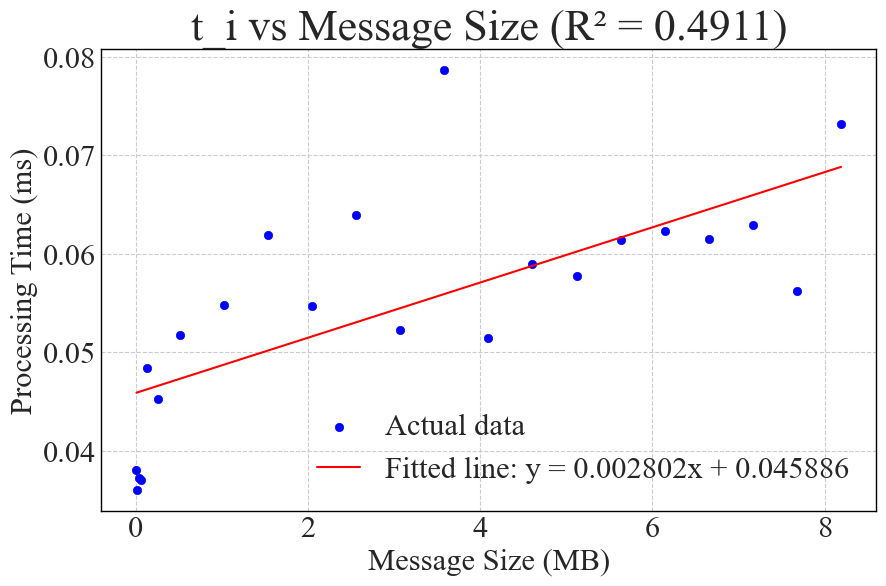

o = 0.003 (us/KB), L (us) = 45.886, R-squared value is 0.491136


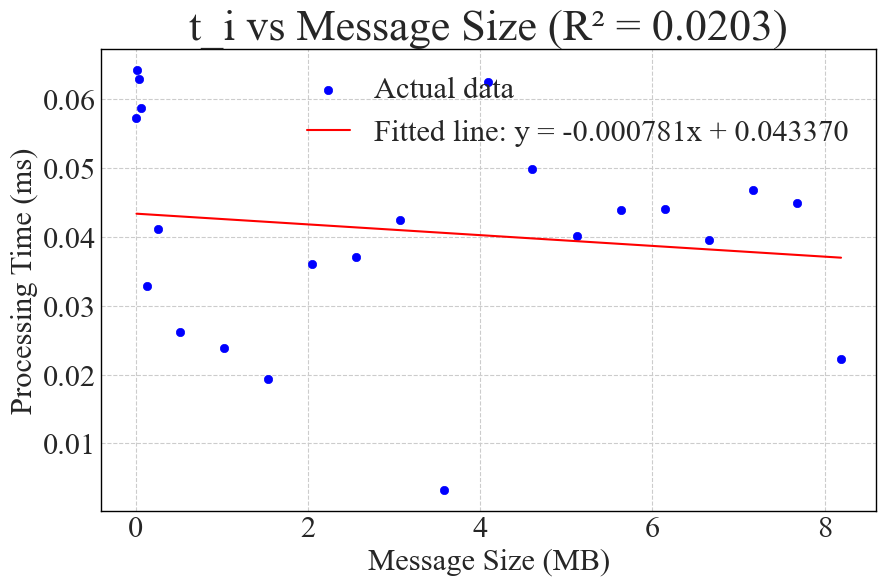

o = -0.001 (us/KB), L (us) = 43.370, R-squared value is 0.020273


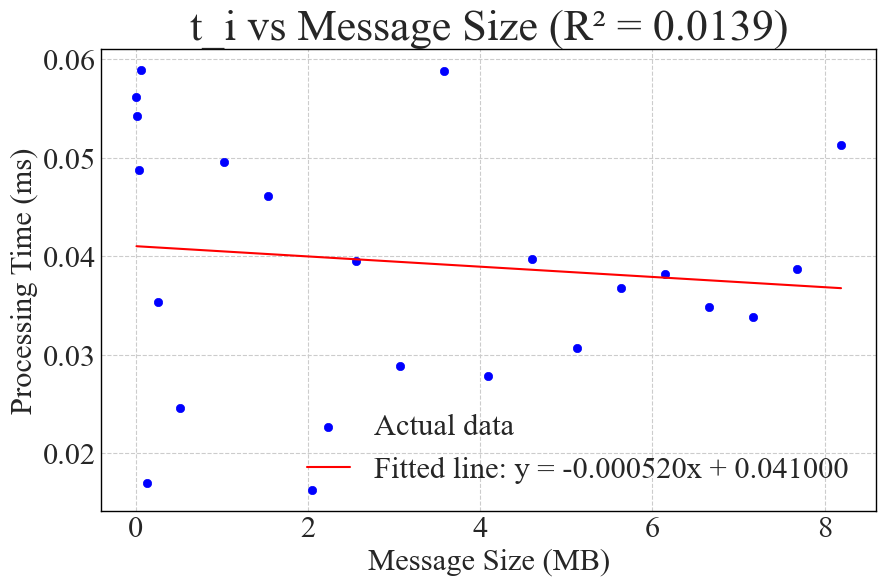

o = -0.001 (us/KB), L (us) = 41.000, R-squared value is 0.013864


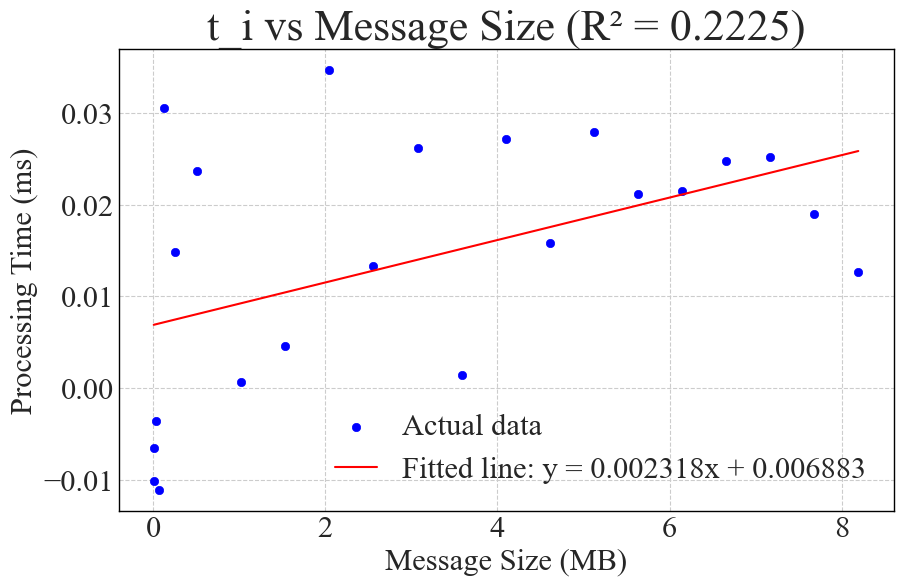

o = 0.002 (us/KB), L (us) = 6.883, R-squared value is 0.222471


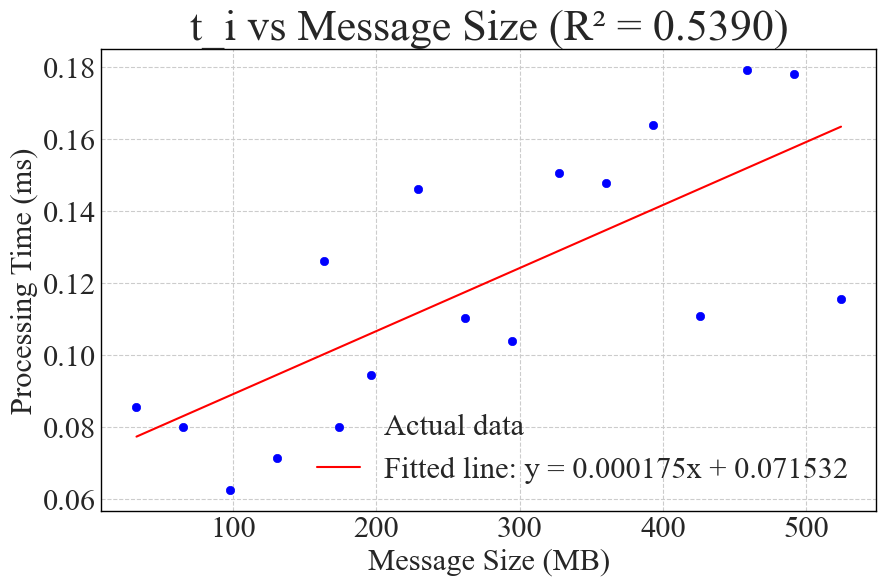

o = 0.000 (us/KB), L (us) = 71.532, R-squared value is 0.538998


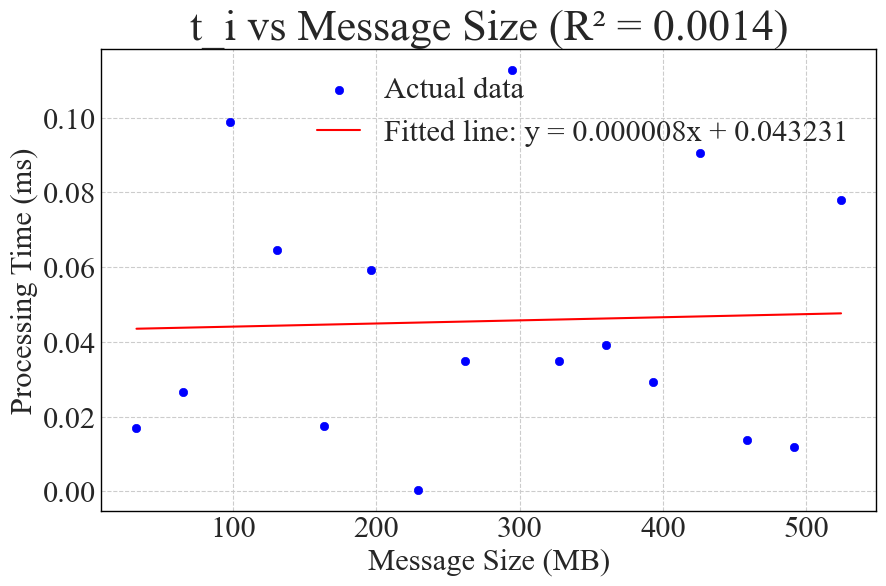

o = 0.000 (us/KB), L (us) = 43.231, R-squared value is 0.001448


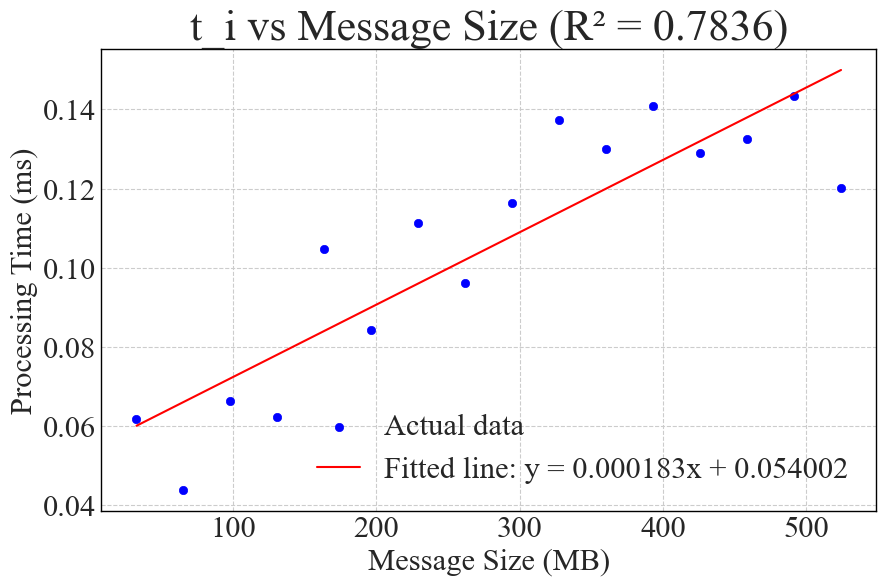

o = 0.000 (us/KB), L (us) = 54.002, R-squared value is 0.783553


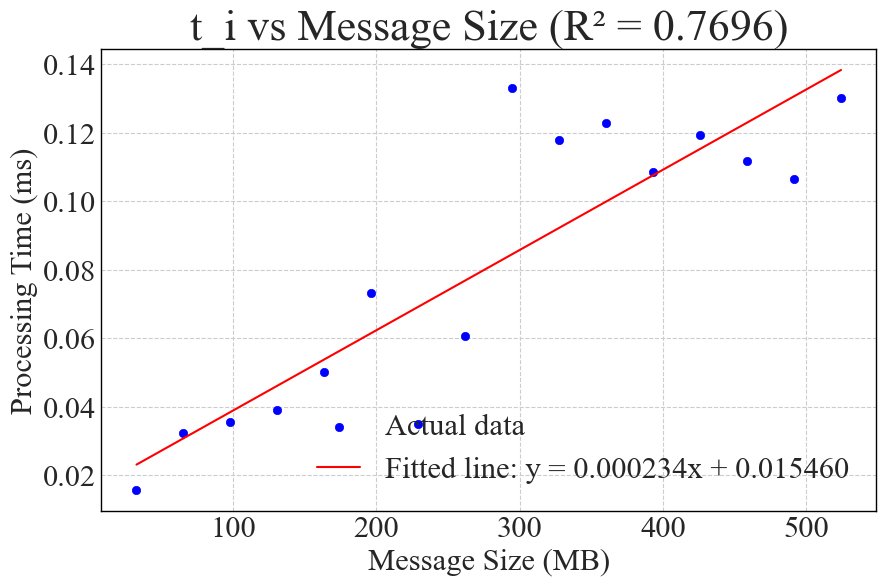

o = 0.000 (us/KB), L (us) = 15.460, R-squared value is 0.769617


In [3956]:

chunk_size_LL128 = 0.5487674169 # MB

number_channels = 16

inflection_point = chunk_size_LL128 * number_channels * 1024 * 1

results = analyze_all_L_timings(df_r24_LL128, df_r16_up_LL128, df_r0_LL128, df_r16_down_LL128, 8, inflection_point, inflection_point, 524288, 1)

# Large message results
L_send_large_LL128 = results['L_send_large']
L_rrs_large_LL128 = results['L_rrs_large']
L_rrcs_large_LL128 = results['L_rrcs_large']
L_rcs_large_LL128 = results['L_rcs_large']

# Small message results
L_send_small_LL128 = results['L_send_small']
L_rrs_small_LL128 = results['L_rrs_small']
L_rrcs_small_LL128 = results['L_rrcs_small']
L_rcs_small_LL128 = results['L_rcs_small']

o_send_small_LL128 = results['o_send_small']
o_rrs_small_LL128 = results['o_rrs_small']
o_rrcs_small_LL128 = results['o_rrcs_small']
o_rcs_small_LL128 = results['o_rcs_small']

In [3957]:
import statistics

# Option 1: Using a list of dataframes
dataframes = [df_r0_LL128, df_r8_LL128, df_r16_up_LL128, df_r16_down_LL128, df_r17_LL128, df_r24_LL128]
BW  = analyze_chunk_speeds(dataframes)

print(f"the BW for the tree is {BW: 3f} GB/s")

the BW for the tree is  116.402182 GB/s


             msg  latency (us)  BW (GB/s) algorithm  nnodes protocol  nchannels  latency_pre (us)  BW_pre (GB/s)  prediction_error (%)
0           4096         267.1       0.03      TREE    16.0    LL128          1        301.606225       0.026949             12.918841
1           8192         245.2       0.07      TREE    16.0    LL128          1        301.606225       0.053898             23.004170
2          16384         229.3       0.14      TREE    16.0    LL128          2        301.606225       0.107796             31.533461
3          32768         232.3       0.28      TREE    16.0    LL128          4        301.606225       0.215592             29.834793
4          65536         234.3       0.56      TREE    16.0    LL128          8        301.606225       0.431185             28.726515
5         131072         236.7       1.10      TREE    16.0    LL128         16        301.606225       0.862369             27.421303
6         262144         238.0       2.19      TREE    

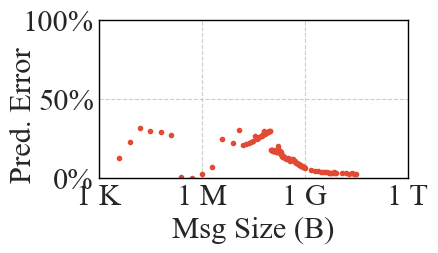

In [3958]:
# use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.

number_nodes = 16
gpus_per_node = 8
chunk_size_LL128 = 0.5487674169 # MB
number_channels = 16

# In the LL128 protocol, I discovered that the reduce/copy time for the first chunk is not needed, 
# as LL128 protocol appears to skip this operation. 
# In contrast, the Simple protocol requires this operation, 
# as evidenced by the reduceCopy() function in primitives_simple.h.
df_sweep_data_ll128_tree_v1 = df_sweep_data_ll128_tree.with_columns([
    (pl.when(pl.min_horizontal(chunk_size_LL128*number_channels, pl.col("msg")/1e6) * 1e3 * o_rrs_small_LL128 + L_rrs_small_LL128 < L_rrs_large_LL128)
     .then(
         # Small message case
         ((pl.min_horizontal(chunk_size_LL128*number_channels, pl.col("msg")/1e6) * 1e3 * 
           ((o_rrs_small_LL128 + o_rcs_small_LL128) * (pl.col("nnodes").log(2)-1) + o_send_small_LL128 + o_rrcs_small_LL128)) 
          + L_send_small_LL128 + (pl.col("nnodes").log(2)-1) * (L_rrs_small_LL128 + L_rcs_small_LL128) + L_rrcs_small_LL128
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL128, 0) * 1e3 / BW)
     )
     .otherwise(
         # Large message case
         (L_send_large_LL128 + (pl.col("nnodes").log(2)-1) * (L_rrs_large_LL128 + L_rcs_large_LL128) + L_rrcs_large_LL128
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL128, 0) * 1e3 / BW)
     )).alias("latency_pre (us)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_ll128_tree_v1 = df_sweep_data_ll128_tree_v1.with_columns([
    (pl.col("msg") * 0.001 * (2*(pl.col("nnodes") * gpus_per_node - 1)/(pl.col("nnodes") * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_ll128_tree_v1_csv = df_sweep_data_ll128_tree_v1.with_columns([
    ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
])

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df_sweep_data_ll128_tree_v1_csv.to_pandas())

df_sweep_data_ll128_tree_v1_csv.to_pandas().to_csv('model0.csv', index=False)

plot_prediction_error(
    df_sweep_data_ll128_tree_v1,
    figsize=(5, 3),
    pdf_filename="allreduce_tree_LL128_pre_error_v1.pdf",
    y_ticks=[0.0, 0.50, 1.00],
    y_labels=["0%", "50%", "100%"],
    xlabel="Msg Size (B)",
    ylabel="Pred. Error",
    legend=False,
    protocol="LL128"
)

📄 Plot saved to: allreduce_tree_ll128_pre_comparison_v1.pdf


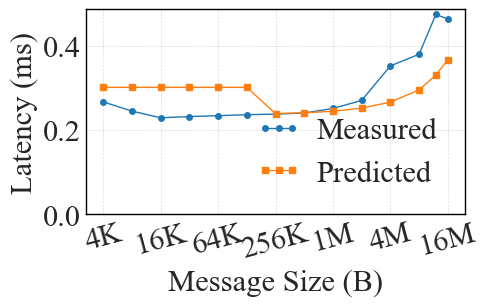

In [3959]:
plot_latency_comparison(
    df=df_sweep_data_ll128_tree_v1,
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='Latency (ms)',
    pdf_filename='allreduce_tree_ll128_pre_comparison_v1.pdf',
    protocol="LL128"
)

📄 Plot saved to: allreduce_tree_ll128_BW_pre_comparison_v1.pdf


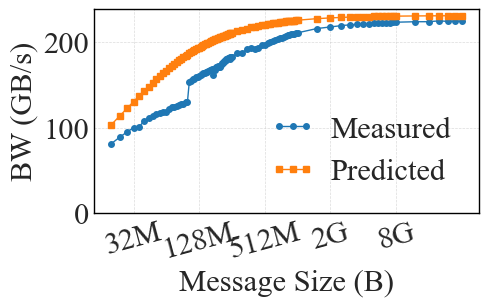

In [3960]:
plot_BW_comparison(
    df=df_sweep_data_ll128_tree_v1,
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='BW (GB/s)',
    pdf_filename='allreduce_tree_ll128_BW_pre_comparison_v1.pdf' 
)

### GPU Scale Prediction

In [3961]:
# df_sweep_data_ll128_tree = df_sweep_data_means.filter(
#     (pl.col("algorithm") == "tree") & 
#     (pl.col("protocol") == "ll128") & 
#     (pl.col("msg") == 17179869184) &
#     (pl.col("nnodes") > 2) 
# )

# print(df_sweep_data_ll128_tree)

In [3962]:
# # use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.

# gpus_per_node = 8
# chunk_size_LL128 = 0.5487674169 # MB
# number_channels = 16

# # In the LL128 protocol, I discovered that the reduce/copy time for the first chunk is not needed, 
# # as LL128 protocol appears to skip this operation. 
# # In contrast, the Simple protocol requires this operation, 
# # as evidenced by the reduceCopy() function in primitives_simple.h.
# df_sweep_data_ll128_tree_v1 = df_sweep_data_ll128_tree.with_columns([
#     (pl.when(pl.col("msg") < 131072)
#      .then(
#          # Small message case
#          ((pl.min_horizontal(chunk_size_LL128*number_channels, pl.col("msg")/1e6) * 1e3 * 
#            ((G_rrs_reverse_small_LL128 + G_rcs_reverse_small_LL128) * (pl.col("nnodes").log(2)-1) + G_send_reverse_small_LL128 + G_rrcs_reverse_small_LL128)) 
#           + L_send_small_LL128 + (pl.col("nnodes").log(2)-1) * (L_rrs_small_LL128 + L_rcs_small_LL128) + L_rrcs_small_LL128
#           + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL128, 0) * 1e3 / G_LL128_small)
#      )
#      .otherwise(
#          # Large message case
#          ((pl.min_horizontal(chunk_size_LL128*number_channels, pl.col("msg")/1e6) * 1e3 * 
#            ((G_rrs_reverse_large_LL128 + G_rcs_reverse_large_LL128) * (pl.col("nnodes").log(2)-1) + G_send_reverse_large_LL128 + G_rrcs_reverse_large_LL128)) 
#           + L_send_large_LL128 + (pl.col("nnodes").log(2)-1) * (L_rrs_large_LL128 + L_rcs_large_LL128) + L_rrcs_large_LL128
#           + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL128, 0) * 1e3 / G_LL128_large)
#      )).alias("latency_pre (us)")
# ])

# # Then, create the bandwidth column using the newly created latency column
# df_sweep_data_ll128_tree_v1 = df_sweep_data_ll128_tree_v1.with_columns([
#     (pl.col("msg") * 0.001 * (2*(pl.col("nnodes") * gpus_per_node - 1)/(pl.col("nnodes") * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
# ])

# # Then, create the bandwidth column using the newly created latency column
# df_sweep_data_ll128_tree_v1_csv = df_sweep_data_ll128_tree_v1.with_columns([
#     ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
# ])

# with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
#         print(df_sweep_data_ll128_tree_v1_csv.to_pandas())

# df_sweep_data_ll128_tree_v1_csv.to_pandas().to_csv('model0.csv', index=False)

# plot_prediction_error_nodes(
#     df_sweep_data_ll128_tree_v1,
#     figsize=(5, 3),
#     pdf_filename="allreduce_tree_LL128_pre_error_v1_nodes.pdf",
#     y_ticks=[0.0, 0.04, 0.08],
#     y_labels=["0%", "4%", "8%"],
#     xlabel="# Nodes",
#     ylabel="Pred. Error",
#     legend=False
# )

In [3963]:
# plot_latency_comparison_nodes(
#     df=df_sweep_data_ll128_tree_v1,
#     y_cols=['latency (us)', 'latency_pre (us)'],
#     labels=['Measured', 'Predicted'],
#     markers=['o', 's'],
#     colors=['#1f77b4', '#ff7f0e'],
#     xlabel='# Nodes',
#     ylabel='Latency (ms)',
#     pdf_filename='allreduce_tree_ll128_pre_comparison_v1_nodes.pdf',
#     protocol="LL128"
# )